# Практическая работа №4.2. Отток клиентов телеком-оператора

<a id=content></a>
### Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Обработка наименований признаков: приведение к нижнему регистру](#2.1.)
    <br>[2.2. Преобразование типов данных](#2.2.)
    <br>[2.3. Обработка дубликатов](#2.3.)
    <br>[2.4. Обработка аномальных значений](#2.4.)
3. [<b>Разведочный анализ данных</b>](#3)
    <br>[3.1. Описательная статистика и вычисление основных статистических показателей для числовых данных в контексте `churn`-анализа](#3.1.)
    <br>[3.2. Корреляционный анализ](#3.2.)
    <br>[3.3. Визуализация категориальных данных](#3.3.)
    <br>[3.4. Визуализация интервальных данных](#3.4.)
    <br>[3.5. Ключевые признаки в разрезе административно-территориального деления](#3.5.)
    <br>[3.6. Услуги связи в целом](#3.6.)
    <br>[3.7. Услуги международной связи](#3.7.)
    <br>[3.8. Услуга голосовой почты](#3.8.)
    <br>[3.9. Поддержка клиентов](#3.9.)
    <br>[3.10. Прибыльность услуг](#3.10.)
4. [<b>Проверка статистических гипотез</b>](#4)
    <br>[4.1. Клиенты, которые расторгли договор предоставления телеком-услуг, обращаются в службу поддержки чаще, чем клиенты, продолжающие пользоваться услугами](#4.1.)
    <br>[4.2. Клиенты, которые расторгли договор предоставления телеком-услуг, чаще подключают международный план по сравнению с теми, кто остаётся](#4.1.)
5. [<b>Сегментация и портретированные клиентов</b>](#5)
    <br>[5.1. Какие данные о клиентах у нас есть?](#5.1.)
    <br>[5.2. Какие признаки и характеристики, влияющие на отток, мы будем использовать для сегментации клиентов?](#5.2.)
    <br>[5.3. Какие сложности и проблемы могут возникнуть при сегментации клиентов и как их можно решить?](#5.3.)
    <br>[5.4. Предположения о типах и видах телеком-услуг, которыми пользуются клиенты](#5.4.)
    <br>[5.5. Какие маркетинговые стратегии и инструменты мы можем использовать для работы с каждым сегментом?](#5.5.)
6. [<b>Вывод</b>](#6)

<a id=descr_proj></a>
## Описание проекта

Датасет `telecom_churn.csv` содержит информацию о 3333 клиентах телекоммуникационной компании и включает 20 признаков, описывающих их демографические характеристики, тарифные планы, модель использования услуг связи и взаимодействие со службой поддержки. Основная цель анализа этого набора данных — выявление факторов, влияющих на отток клиентов, то есть на решение клиента прекратить пользоваться услугами оператора. Среди признаков присутствуют как числовые (например, длительность звонков в дневное, вечернее и ночное время, количество обращений в службу поддержки), так и категориальные (например, наличие международного плана, подключение голосовой почты, штат проживания клиента). Целевая переменная `Churn` является бинарной и указывает, ушёл ли клиент. Данные имеют стратегическое значение для прогнозирования оттока, сегментации клиентов и разработки стратегий удержания.

<a id=descr_data></a>
## Описание данных

В работу поступил массив данных по оттоку клиентов телеком-оператора `telecom_churn.csv` размером 3 333 строк на 20 столбцов следующего содержания:

|№ п/п|Наименование признака   |Описание признака|Ед.|Размах значений признака|
|-----|------------------------|:----------------|:--|:-----------------------|
|1.   |`State`                 |Буквенный код штата|уникальный идентификационный код|51 уникальный идентификационный код|
|2.   |`Account length`        |Длительность периода обслуживания клиента|месяц|от 1 до 243|
|3.   |`Area code`             |Префикс номера телефона|уникальный префикс номера телефона|3 уникальных префикса|
|4.   |`International plan`    |Международный роуминг|услуга подключена / не подключена| да / нет |
|5.   |`Voice mail plan`       |Голосовая почта                               |услуга подключена / не подключена| да / нет |
|6.   |`Number vmail messages` |Количество голосовых сообщений                |единицы|от 0 до 51|
|7.   |`Total day minutes`     |Общая длительность разговоров днём            |минуты |от 0 до 350.8|
|8.   |`Total day calls`       |Общее количество звонков днём                 |единицы|от 0 до 165|
|9.   |`Total day charge`      |Общая сумма оплаты за услуги днём             |`$`    |от 0 до 59.64|
|10.  |`Total eve minutes`     |Общая длительность разговоров вечером         |минуты |от 0 до 363.7|
|11.  |`Total eve calls`       |Общее количество звонков вечером              |единицы|от 0 до 170|
|12.  |`Total eve charge`      |Общая сумма оплаты за услуги вечером          |`$`    |от 0 до 30.91|
|13.  |`Total night minutes`   |Общая длительность разговоров ночью           |минуты |от 23.2 до 395|
|14.  |`Total night calls`     |Общее количество звонков ночью                |единицы|от 33 до 175|
|15.  |`Total night charge`    |Общая сумма оплаты за услуги ночью            |`$`    |от 1.04 до 17.77|
|16.  |`Total intl minutes`    |Общая длительность международных разговоров   |минуты |от 0 до 20|
|17.  |`Total intl calls`      |Общее количество международных разговоров     |единицы|от 0 до 20|
|18.  |`Total intl charge`     |Общая сумма оплаты за международные разговоры |`$`    |от 0 до 5.4|
|19.  |`Customer service calls`|Число обращений в службу поддержки            |единицы|от 0 до 9|
|20.  |`Churn`                 |Признак оттока клиента                        |клиент остался / клиент ушёл|да / нет|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датафрейму.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.feature_selection import mutual_info_classif # для установления взаимосвязи между признаками

# настройки визуализации
%config InlineBackend.figure_format = 'svg' # наиболее чёткое отображение графиков
%matplotlib inline
plt.rc('figure', figsize=(12, 6), facecolor='white')

# устанавливаем опцию вывода всех столбцов
pd.set_option('display.max_columns', None)

# устанавливаем опцию вывода максимальной ширины столбцов
pd.set_option('display.max_colwidth', None)

import warnings
warnings.simplefilter('ignore')

In [2]:
# загрузка датафрейма
df = pd.read_csv('tgu_4.2._telecom_churn.csv')

In [3]:
# выводим датафрейм для ознакомления
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
# общие сведения о типах данных и их полноте
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

**Вывод:** для проведения исследования нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов. Выполнена загрузка исходных данных методом `read_csv`. В работу поступил датафрейм `tgu_4.2._telecom_churn.csv`, содержащий информацию о клиентах телеком-оператора. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()` мы получили первичную информацию для статистического анализа. Так, исходный датафрейм содержит 3333 строк в разрезе 20 признаков. Пропущенные значения в данных отсутствуют. Представляется целесообразным преобразование типов данных по признакам `International plan` и `Voice mail plan` в булев тип данных в соответствии логикой исследования.

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1.></a>
### 2.1. Обработка наименований признаков

In [5]:
# приведение наименований столбцов к нижнему регистру
df.columns = df.columns.str.lower()

<a id=2.2.></a>
### 2.2. Преобразование типов данных

In [6]:
# замена значений признаков `International plan` и `Voice mail plan` на булев тип
df = df.replace({'international plan' : {'Yes':True, 'No':False}, 
                 'voice mail plan' : {'Yes':True, 'No':False}})

<a id=2.3.></a>
### 2.3. Обработка дубликатов

In [7]:
# проверка на полные дубликаты
df.duplicated().sum()

np.int64(0)

<a id=2.4.></a>
### 2.4. Обработка аномальных значений

In [8]:
# пересобираем признаки датафрейма в порядке: кол-во минут, кол-во звонков, $ за период, остальные характеристики 
df = df[['total day minutes', 'total eve minutes', 'total night minutes', 'total intl minutes', \
         'total day calls', 'total eve calls', 'total night calls', 'total intl calls',\
         'total day charge', 'total eve charge', 'total night charge', 'total intl charge',\
         'international plan', 'voice mail plan', 'number vmail messages', \
         'state', 'account length', 'area code', 'customer service calls', 'churn']]

In [9]:
# описательные статистики
df.describe().round()

,total day minutes,total eve minutes,total night minutes,total intl minutes,total day calls,total eve calls,total night calls,total intl calls,total day charge,total eve charge,total night charge,total intl charge,number vmail messages,account length,area code,customer service calls
count,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0,3333.0
mean,180.0,201.0,201.0,10.0,100.0,100.0,100.0,4.0,31.0,17.0,9.0,3.0,8.0,101.0,437.0,2.0
std,54.0,51.0,51.0,3.0,20.0,20.0,20.0,2.0,9.0,4.0,2.0,1.0,14.0,40.0,42.0,1.0
min,0.0,0.0,23.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,408.0,0.0
25%,144.0,167.0,167.0,8.0,87.0,87.0,87.0,3.0,24.0,14.0,8.0,2.0,0.0,74.0,408.0,1.0
50%,179.0,201.0,201.0,10.0,101.0,100.0,100.0,4.0,30.0,17.0,9.0,3.0,0.0,101.0,415.0,1.0
75%,216.0,235.0,235.0,12.0,114.0,114.0,113.0,6.0,37.0,20.0,11.0,3.0,20.0,127.0,510.0,2.0
max,351.0,364.0,395.0,20.0,165.0,170.0,175.0,20.0,60.0,31.0,18.0,5.0,51.0,243.0,510.0,9.0


На основе представленных описательных статистик можно сделать следующие выводы:
* `аccount length` (длительность использования аккаунта). В среднем клиенты используют сервис около 101 дня (медиана совпадает со средним), с типичным разбросом ±40 дней. Минимальная длительность — 1 день, максимальная — 243 дня.
* `area code` (префикс номера телефона) распределён неравномерно. Среднее значение — 437, но квартили (`25%` — 408, `50%` — 415, `75%` — 510) и стандартное отклонение (42) указывают на наличие нескольких основных регионов. Минимальный и наиболее часто встречающийся код — 408, максимальный — 510.
* `number vmail messages` (количество сообщений на голосовой почте). Большинство клиентов не используют голосовую почту — `медиана` и `25-й процентиль` равны `0`. Однако у части пользователей наблюдается активное использование (до 51 сообщения), среднее — 8 сообщений при высоком разбросе (`std` = `14`).
* `total day minutes / calls / charge` (дневная активность). В среднем клиенты разговаривают 180 минут в день (медиана — 179), совершая около 100 звонков. Стоимость дневных звонков в среднем составляет 31 доллар. Распределение близко к симметричному, но с заметной вариативностью (`std` ≈ `54` для минут, `20` для звонков).
* `total eve minutes / calls / charge` и `total night minutes / calls / charge` (вечерняя и ночная активность). Статистики для вечерних и ночных звонков почти идентичны по структуре. Среднее время разговоров — около 201 минуты, ~100 вызовов, стоимость — 17 и 9 долларов соответственно. Однако ночная тарификация ниже, что логично. Интересно, что минимальное ночное время — 23 минуты (в отличие от `0` у дневных и вечерних), что может указывать на пакетные тарифы.
* `total intl minutes / calls / charge` (международные звонки). Средняя продолжительность — 10 минут при 4 звонках в месяц, стоимость — 3 доллара. Распределение умеренно скошено вправо: медиана совпадает со средним, но есть выбросы (максимум — 20 минут, 20 звонков, 5 долларов).
* `customer service calls` (обращения в службу поддержки). В среднем клиенты обращаются 2 раза, медиана — 1 обращение. При этом 75% клиентов обращаются не более 2 раз, но есть аномальные случаи — до 9 обращений, что может сигнализировать о проблемах у отдельных пользователей.

На основе предоставленных описательных статистик можно выявить признаки, в которых присутствуют аномальные значения (выбросы), ориентируясь на следующие косвенные признаки:
* Очень большое расстояние между 75-м процентилем (`Q3`) и максимумом по сравнению с межквартильным размахом (`IQR = Q3 – Q1`).  
* Значительное отличие максимума от медианы и среднего при умеренном `std` (стандартном отклонении).  
* Несоответствие между `медианой = 0` и положительным средним (при сильной асимметрии), что часто указывает на редкие, но большие значения.

Итоговый список признаков, в которых наиболее вероятны выбросы:
* `total intl calls` Медиана = 4, 75% ≤ 6, но максимум = 20 при среднем = 4 и std = 2. Значения около 20 звонков — явное отклонение от общей картины и потенциальные выбросы.
* `number vmail messages` Медиана = 0, 75% клиентов имеют ≤20 сообщений, но максимум = 51 при среднем = 8 и std = 14. Это указывает на редкие случаи с аномально высоким числом сообщений голосовой почты.
* `customer service calls` Медиана = 1, 75% клиентов звонят в техподдержку до двух раз, однако зафиксировано максимальное значение = 9 при среднем = 2 и std = 1. Значения 7–9 обращений — редкие и могут считаться выбросами, особенно на фоне типичного поведения (0–2 обращения).
* `total day minutes` / `total eve minutes` / `total night minutes` Также могут содержать умеренные выбросы, но менее экстремальные по сравнению с вышеуказанными. Для этого признака Q3 = 216, максимум = 351, IQR ≈ 72. По правилу 1.5×IQR верхняя граница ≈ 216 + 1.5×72 = 324, а максимум = 351, следовательно, возможны выбросы выше 324. Аналогично для вечерних минут: Q3 = 235, IQR ≈ 68 → граница ≈ 337, максимум = 364 → небольшое превышение. Для ночных минут: Q3 = 235, максимум = 395 → верхняя граница ≈ 337, значит, значения от ~338 до 395 — вероятные выбросы.

В целом, **данные демонстрируют умеренную вариативность по большинству показателей**, за исключением голосовой почты и обращений в поддержку, где распределения явно смещены вправо. Ночные звонки, судя по минимальному значению, используются всеми клиентами, в отличие от других временных интервалов.

In [10]:
# расчёт количества строк, содержащих выбросы в данных
df[(df['number vmail messages'] > 20) & (df['customer service calls'] > 2) & (df['total intl calls'] > 6)].shape[0]

25

В общей массе данных выбросы составляют всего 0.75% и могут послужить важными сигналами о поведении отточных клиентов, поэтому эти данные будут сохранены и учтены при исследовании.

**Вывод:** на этапе предварительной обработки данных наименования признаков были приведены к нижнему регистру. Также по признакам `International plan` и `Voice mail plan` было выполнено преобразование в булев тип данных. В целях выявления аномальных значений в данных методом `describe()` были получены описательные статистики по числовым признакам. По признакам `number vmail messages`, `customer service calls`, `total intl calls` установлено наличие выбросов, общее количество таких строк в датасете равно 25 или  0,75%. Эти данные мы можем сохранить для дальнейшего исследования.

<a id=3.></a>
## Шаг 3. Разведочный анализ данных

<a id=3.1.></a>
### 3.1. Описательная статистика и вычисление основных статистических показателей

- формирование групп клиентов в соответствии с признаком оттока;
- расчёт описательных статистик двух групп по признаку оттока.

In [11]:
# формирование групп пользователей по признаку оттока
сhurn = df[df['churn'] == True]
retention = df[df['churn'] == False]

In [12]:
# описательные статистики по отточной группе клиентов
сhurn.describe().round(1)

,total day minutes,total eve minutes,total night minutes,total intl minutes,total day calls,total eve calls,total night calls,total intl calls,total day charge,total eve charge,total night charge,total intl charge,number vmail messages,account length,area code,customer service calls
count,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0,483.0
mean,206.9,212.4,205.2,10.7,101.3,100.6,100.4,4.2,35.2,18.1,9.2,2.9,5.1,102.7,437.8,2.2
std,69.0,51.7,47.1,2.8,21.6,19.7,20.0,2.6,11.7,4.4,2.1,0.8,11.9,39.5,42.8,1.9
min,0.0,70.9,47.4,2.0,0.0,48.0,49.0,1.0,0.0,6.0,2.1,0.5,0.0,1.0,408.0,0.0
25%,153.2,177.1,171.2,8.8,87.5,87.0,85.0,2.0,26.1,15.1,7.7,2.4,0.0,76.0,408.0,1.0
50%,217.6,211.3,204.8,10.6,103.0,101.0,100.0,4.0,37.0,18.0,9.2,2.9,0.0,103.0,415.0,2.0
75%,266.0,249.4,239.8,12.8,116.5,114.0,115.0,5.0,45.2,21.2,10.8,3.5,0.0,127.0,510.0,4.0
max,350.8,363.7,354.9,20.0,165.0,168.0,158.0,20.0,59.6,30.9,16.0,5.4,48.0,225.0,510.0,9.0


In [13]:
# описательные статистики по удерживаемой группе клиентов
retention.describe().round(1)

,total day minutes,total eve minutes,total night minutes,total intl minutes,total day calls,total eve calls,total night calls,total intl calls,total day charge,total eve charge,total night charge,total intl charge,number vmail messages,account length,area code,customer service calls
count,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0,2850.0
mean,175.2,199.0,200.1,10.2,100.3,100.0,100.1,4.5,29.8,16.9,9.0,2.7,8.6,100.8,437.1,1.4
std,50.2,50.3,51.1,2.8,19.8,20.0,19.5,2.4,8.5,4.3,2.3,0.8,13.9,39.9,42.3,1.2
min,0.0,0.0,23.2,0.0,0.0,0.0,33.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,408.0,0.0
25%,142.8,164.5,165.9,8.4,87.0,87.0,87.0,3.0,24.3,14.0,7.5,2.3,0.0,73.0,408.0,1.0
50%,177.2,199.6,200.2,10.2,100.0,100.0,100.0,4.0,30.1,17.0,9.0,2.8,0.0,100.0,415.0,1.0
75%,210.3,233.2,234.9,12.0,114.0,114.0,113.0,6.0,35.8,19.8,10.6,3.2,22.0,127.0,510.0,2.0
max,315.6,361.8,395.0,18.9,163.0,170.0,175.0,19.0,53.6,30.8,17.8,5.1,51.0,243.0,510.0,8.0


При сравнении описательных статистик между группами рассчитывают коэффициент вариации для нормализации изменчивости относительно среднего, особенно когда группы имеют разные масштабы. Также стоит отметить устойчивость коэффициента вариации к сдвигу среднего. При сравнении `mean` и `std` отдельно можно упустить важный паттерн: если и `mean`, и `std` выросли пропорционально, относительная вариабельность не изменилась. Коэффициент вариации покажет это явно: CV ≈ const → распределение “масштабировалось”, но не “деформировалось”. В контексте нашей задачи сегментации групп по признаку оттока представляется важным понять, насколько однородны клиенты внутри каждой из групп.

In [14]:
# сравнение однородности групп
# CV здесь сработает не как строгая математическая метрика, а как сигнал о бимодальности распределения (есть те, кто не пользуется вообще, и те, кто пользуется очень много)
numeric_cols = df.select_dtypes(include='number').columns
cv_by_group = df.groupby('churn')[numeric_cols].apply(lambda x: (x.std() / x.mean()) * 100).T
cv_by_group['difference'] = cv_by_group[True] - cv_by_group[False]
cv_by_group = cv_by_group.sort_values(by='difference', ascending=False).style.background_gradient(cmap='coolwarm', subset=['difference']).format(precision=2, na_rep='–')
cv_by_group

churn,False,True,difference
number vmail messages,161.69,231.83,70.13
total intl calls,53.87,61.28,7.41
total day charge,28.65,33.35,4.70
total day minutes,28.65,33.35,4.70
customer service calls,80.28,83.11,2.84
total day calls,19.75,21.30,1.55
total night calls,19.49,19.87,0.38
area code,9.68,9.77,0.09
total eve calls,19.95,19.61,-0.34
total eve minutes,25.27,24.35,-0.91


В контексте `churn`-анализа расчёт коэффициента вариации по группам «ушёл/остался» (CV, %) можно сделать ряд важных аналитических и стратегических выводов.

**Самые значимые положительные значения разницы** указывают, где разброс у ушедших клиентов значительно выше, чем у оставшихся. Такие значения зафиксированы по следующим признакам:
* `number vmail messages` (количество сообщений на голосовой почте), `+70,13%`. У оставшихся CV ≈ 162%, у ушедших — 232%. Это означает, что использование голосовой почты у ушедших клиентов гораздо менее предсказуемо: большинство её не используют (значения = 0), но есть подгруппа с очень высокой активностью. Возможно, голосовая почта связана с определённым сегментом ушедших клиентов (например, корпоративные пользователи vs. частные).
* `total intl calls` (общее количество международных вызовов), `7.41%`. Повышенный CV у ушедших (+7.41%) говорит о гетерогенности этой группы: одни почти не звонят за границу, другие — активно. Это может указывать на разные причины ухода: одни — из-за высоких расходов на международную связь, другие — из-за её отсутствия (неудовлетворённость услугой).
* `total day charge` и `total day minutes` (стоимость дневных звонков и общая длительность дневных звонков) , `+4.70%`. У ушедших и среднее выше, и разброс больше, то есть среди них больше "тяжёлых" пользователей, но также есть и "лёгкие". Возможна недооценка стоимости у активных клиентов, поэтому они уходят к конкурентам с лучшими тарифами.
* `customer service calls` (количество обращений в службу поддержки), `+2.84%`. CV вырос с 80% до 83% — небольшое, но устойчивое увеличение. У ушедших клиентов поведение в обращениях менее однородно: от 0 до 9 звонков (максимум). Это может отражать разные уровни недовольства.

**Самые значимые отрицательные значения разницы** указывают, что у ушедших клиентов поведение более однородно и стабильное, чем у оставшихся:
* `total night minutes` (общая длительность ночных звонков), `–2.57%`. У ушедших ночная активность стабильнее — возможно, они преимущественно «ночные» пользователи без экстремумов.
* `account length` (длительность периода обслуживания клиента), `–1.12%`. Срок обслуживания у ушедших менее разнообразен — возможно, уход происходит в определённый период (например, после окончания договора).
* `total eve charge` и `total night charge` (стоимость вечерных и ночных звонков), `-0.91%` и `-2.57%`. Вечернее и ночное потребление у ушедших клиентов более предсказуемо, и это может свидетельствовать о том, что оставшиеся клиенты - более разнородная группа, включающая как новых, так и давних, как активных, так и пассивных клиентов.

На основании вышеизложенного мы можем говорить о том, что сегментация ушедших клиентов требует построения дополнительных подгрупп / сегментов, поскольку сама по себе эта группа неоднородная и часть ушедших клиентов были "актвиными" (высокие дневные и международные звонки) и, возможно, ушли из-за цены, а другая часть клиентов была "пассивными" (низкие звонки, но при это много обращений в поддержку) и они, возможно, ушли из-за качества сервиса. Самым ярко выраженным **маркером сегментирования** может выступать признак количества сообщений голосовой почты **`number vmail messages`**. Определённая точка риска - это признак `total intl calls`. Клиентам с растущим числом таких вызовов определённо стоит предложить более гибкие тарифы на международную связь.

<a id=3.2.></a>
### 3.2. Корреляционный анализ

* обоснование выбора коэффициента корреляции
* расчёт и визуализация корреляционной матрицы
* на основе матрицы корреляции указать что влияет на отток.

Корреляция — это мера линейной зависимости между двумя числовыми переменными. Самый распространённый способ — коэффициент корреляции Пирсона.

In [15]:
# отбираем только числовые призаки, исключаем из них `area code` как категориальный
corr_cols = ['total day minutes', 'total eve minutes', 'total night minutes',
       'total intl minutes', 'total day calls', 'total eve calls',
       'total night calls', 'total intl calls', 'total day charge',
       'total eve charge', 'total night charge', 'total intl charge',
       'number vmail messages', 'account length', 'customer service calls']

# создаём матрицу корреляции
matrix = df[corr_cols].corr().round(3)

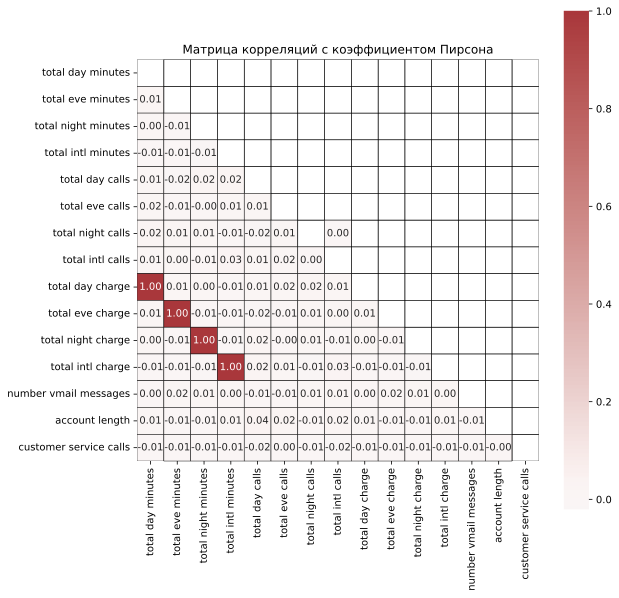

In [16]:
# визуализация матрицы корреляции
plt.figure(figsize=(9, 9))
sns.heatmap(data=matrix, annot=True, square=True, cmap='vlag', fmt='.2f', center=0, linewidths=0.5, linecolor='black', 
            mask=np.triu(matrix))
plt.title('Матрица корреляций с коэффициентом Пирсона')
plt.show()

На полученной матрице корреляции признаков мы видим **линейную зависимость между признаками `total day minutes` / `total day charge`, `total eve minutes` / `total eve charge`, `total night minutes` / `total night charge`, `total intl minutes` / `total intl charge`.** Это значит, что группу признаков `charge` для сегментирования и портретирования клиентов мы можем в дальнейшем не учитывать и все основные характеристики будут получены на основании его парного признака `total minutes`, который является его линейным выражением. 

Очень низкие корреляции (`|r| < 0,04`) означают, что **линейные связи между всеми остальными признаками отсутствуют.** Это говорит о том, что мы не можем полагаться на простые линейные зависимости, и стоит искать нелинейные эффекты взаимодействия признаков.

Любую статистическую связь (линейную, нелинейную, категориальную) между признаком и целевой переменной `churn` показывает **коэффициент взаимной информации** (Mutual Information, MI). `MI` показывает, какое количество информации об истинных классах содержится в кластерах и, наоборот, количество информации о кластерах, содержащихся в кластерах (мера симметрична). Она подходит как для непрерывных, так и для дискретных переменных. Значения MI, близкие к нулю, указывают на то, что два назначения меток в значительной степени независимы, а значения, близкие к единице, указывают на значительное согласие.

In [17]:
# подготовка данных
X = df.drop('churn', axis=1)
y = df['churn']

# закодируем категориальные признаки
X_encoded = X.copy()
for col in ['state', 'area code']:
    X_encoded[col] = pd.factorize(X_encoded[col])[0]

# вычисляем MI
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'MI': mi_scores}).sort_values('MI', ascending=False).round(3)
mi_df

,feature,MI
0,total day minutes,0.054
8,total day charge,0.053
18,customer service calls,0.038
12,international plan,0.024
14,number vmail messages,0.015
3,total intl minutes,0.007
13,voice mail plan,0.007
15,state,0.005
5,total eve calls,0.004
9,total eve charge,0.002


На основании полученных расчётов мы можем утверждать, что наибольшая связь между целевым признаком `churn` присутствует у признаков:
* `total day minutes` и `total day charge` (0.054 и 0.053). У этих признаков также отмечается прямая линейная зависимость, поэтому, для дальнейшего сегментирования и портретирования пользователей мы можем оставить только `total day minutes`. кто больше разговаривает днём — чаще уходит (или наоборот). В дальнейшем необходимо проверить распределение этих признаков у ушедших (churn=1) и оставшихся (churn=0). Возможно, у ушедших клиентов выше средние дневные минуты.
* `customer service calls` (0.038). Это второй по списку и третий по важности признак — и он целочисленный, часто бинаризуется (например, >2 звонков = риск). В `churn`-аналитике это один из самых сильных предикторов: недовольные клиенты звонят чаще.
* `international plan` (0.024). Несмотря на низкую корреляцию, MI = 0.024 — это значимый сигнал. Клиенты с международным тарифом связи зачастую очень чувствительны к качеству связи и к уровню поддержки.
* `number vmail messages` (0.015). Это слабый, но заметный сигнал. Здесь есть одна интересная взаимосвязь: `voice mail plan` имеет ещё меньший MI (0.0066). То есть, для ушедших клиентов важно не просто наличие голосовой почты для галочки, а её активное использование. И именно это напрямую связано с лояльностью клиентов.

Все прочие признаки имеют очень низкий MI и, следовательно, маловероятно, что они сильно влияют на отток в одиночку.

**Выводы:** подводя итоги вышесказанному, для сегментирования внутри отточной группы клиентов и более детального портретирования нам будут нужны следующие признаки:
* **`total day minutes`** — интенсивность использования услуг связи в дневное время суток.  
* **`total intl calls`** — фактический объём использования услуги международной связи (количество звонков).  
* **`number vmail messages`** — фактический объём использования голосовой почты (количество сообщений).  
* **`customer service calls`** — частота обращений в службу поддержки; критическим считается порог более 2 звонков.

<a id=3.3.></a>
### 3.3. Визуализация категориальных данных

С помощью циклической обработки выведем столбчатые диаграммы по признакам `area code`, `international plan`, `voice mail plan`. Признак `state` в виду его многочисленности рассмотрим в отдельной ячейке.

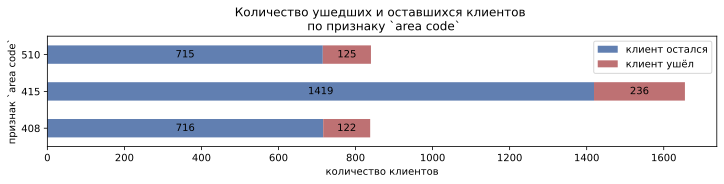

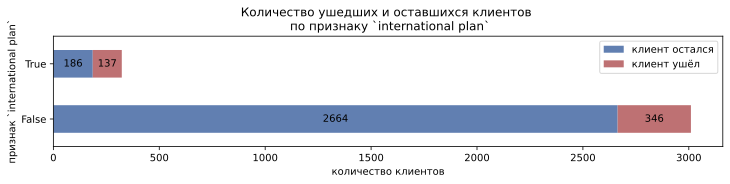

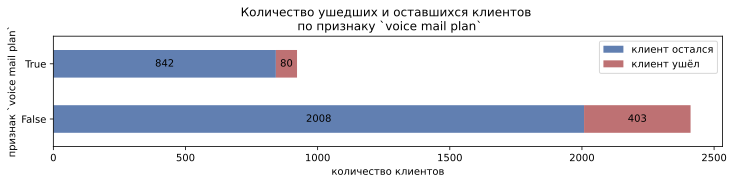

In [18]:
# создаём графики для категориальных признаков
categorial = ['area code', 'international plan', 'voice mail plan']
custom_colors = ['#617FB1', '#BE7173']

for category in categorial:
    # создаём горизонтальную столбчатую диаграмму для каждого признака
    pivot_cat_table = df.pivot_table(index=category, columns='churn', values='account length', aggfunc='count', fill_value=0)
    plot = pivot_cat_table.plot(kind='barh', stacked=True, figsize=(12, 2), color=custom_colors)
    
    for rect in plot.containers:
        for p in rect.patches:
            width = p.get_width()
            height = p.get_height()
            x = p.get_x() + width / 2
            y = p.get_y() + height / 2
            count = f'{width:.0f}'
            plot.annotate(count, (x, y), xytext=(0, 0), textcoords='offset points', ha='center', va='center')

    plt.title(f'Количество ушедших и оставшихся клиентов \n по признаку `{category}`', fontsize=12)
    plt.xlabel('количество клиентов', fontsize=10)
    plt.ylabel(f'признак `{category}`', fontsize=10)
    plt.legend(['клиент остался', 'клиент ушёл'])
    plt.show()

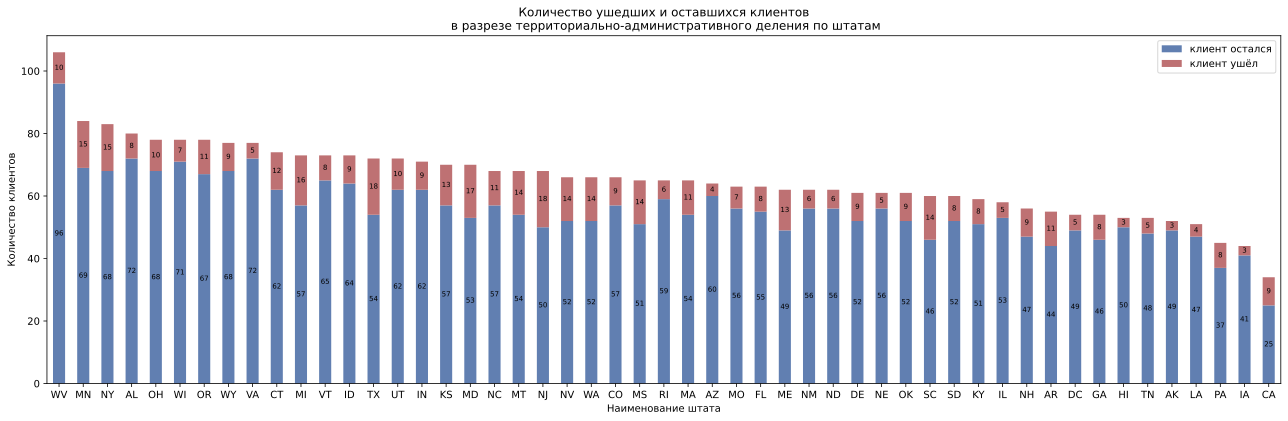

In [19]:
# подготовка данных для диаграммы по признаку 'state'
pivot_state_table = df.pivot_table(index='state', columns='churn', values='account length', aggfunc='count', fill_value=0)
pivot_state_table = pivot_state_table.loc[pivot_state_table.sum(axis=1).sort_values(ascending=False).index]

# вертикальная stacked-диаграмма
plot = pivot_state_table.plot(kind='bar', stacked=True, figsize=(18, 6), color=custom_colors)

# аннотации
for rect in plot.containers:
    for p in rect.patches:
        height = p.get_height()
        if height == 0:
            continue
        width = p.get_width()
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        plot.annotate(f'{height:.0f}', (x, y), xytext=(0, 0), textcoords='offset points', ha='center', va='center', fontsize=7)

plt.title('Количество ушедших и оставшихся клиентов\n в разрезе территориально-административного деления по штатам', fontsize=12)
plt.xlabel('Наименование штата', fontsize=10)
plt.ylabel('Количество клиентов', fontsize=10)
plt.xticks(rotation=0)
plt.legend(['клиент остался', 'клиент ушёл'])
plt.tight_layout()
plt.show()

<a id=3.4.></a>
### 3.4. Визуализация интервальных данных

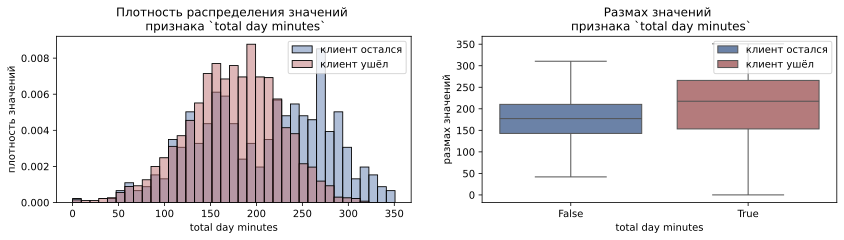

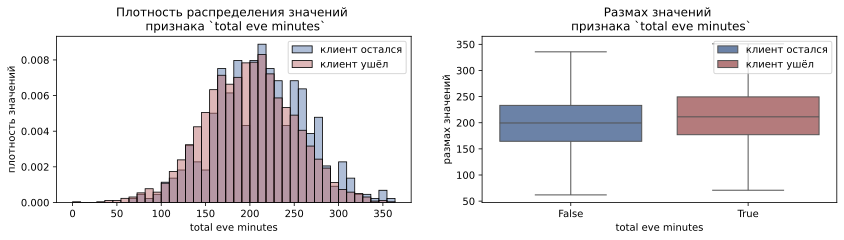

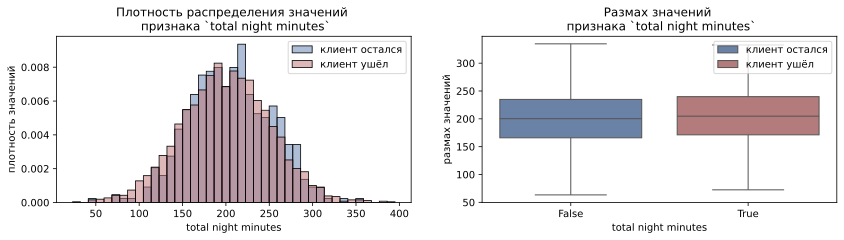

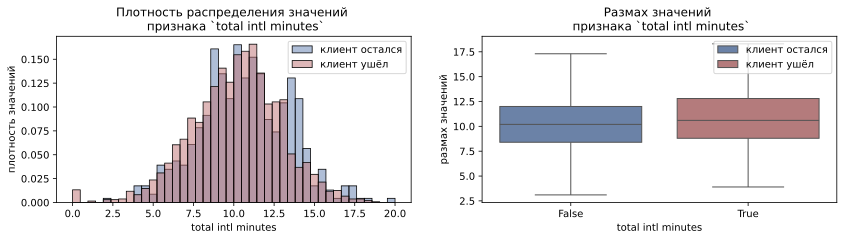

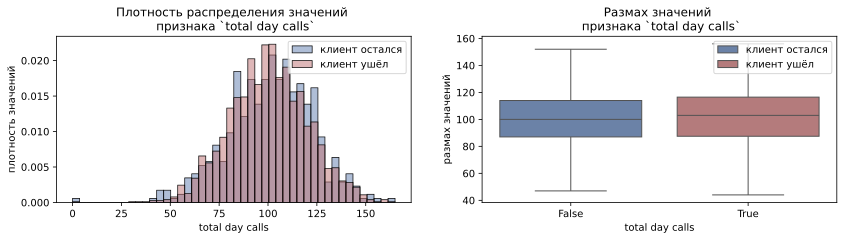

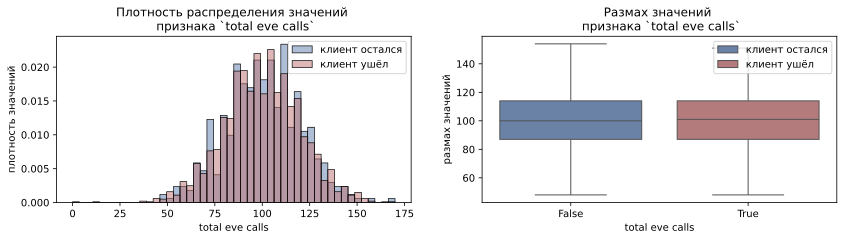

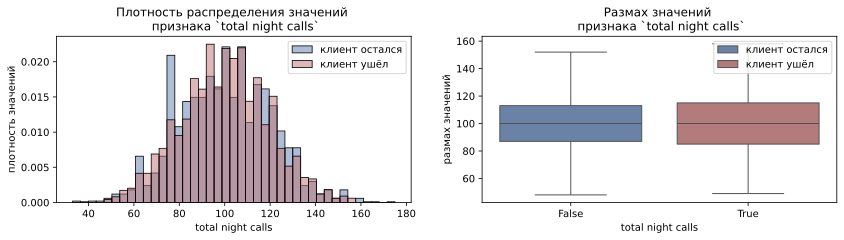

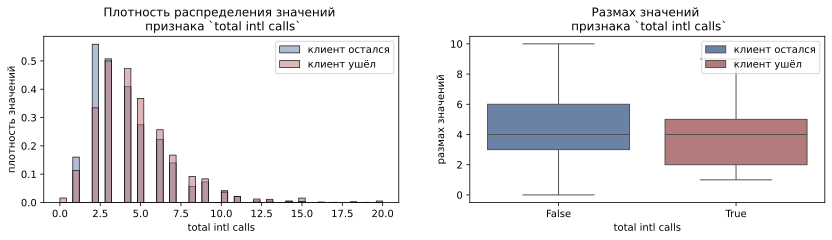

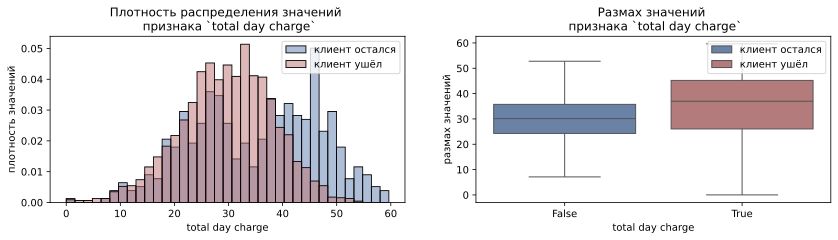

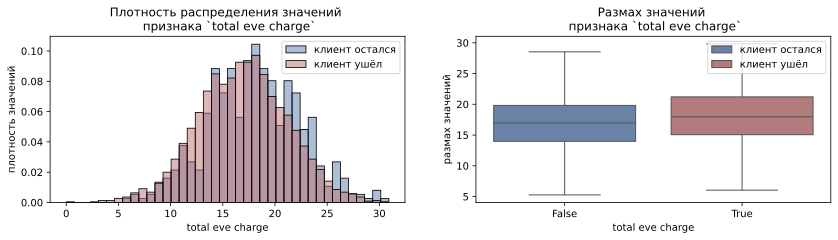

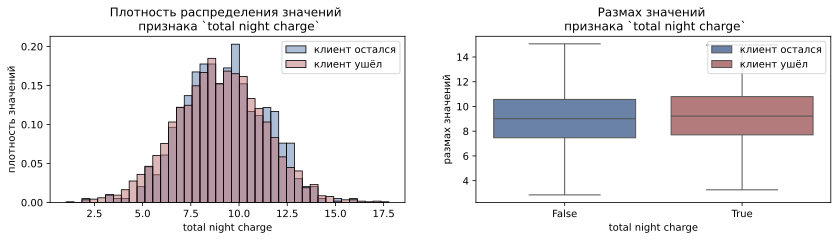

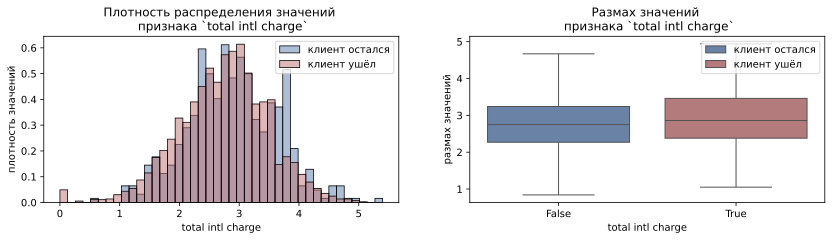

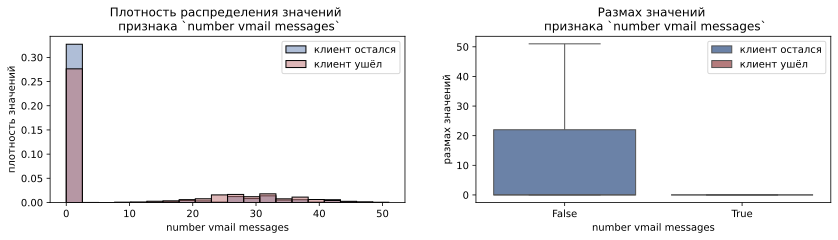

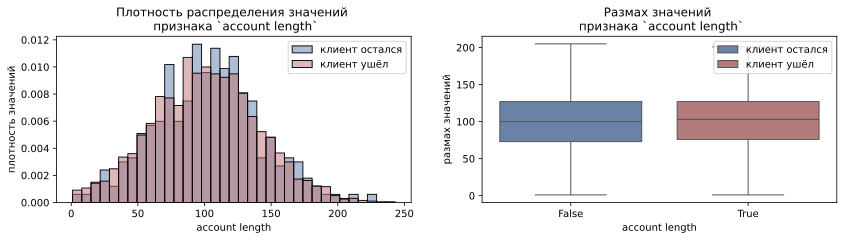

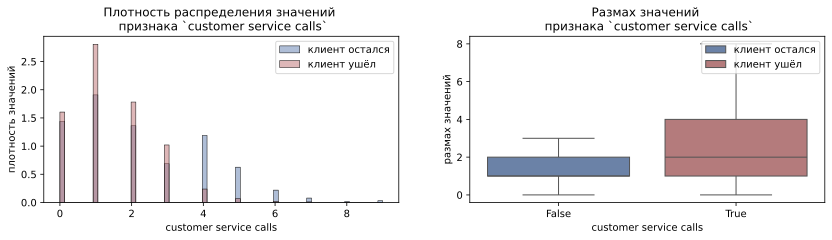

In [20]:
# парные диаграммы для интервальных признаков
interval = ['total day minutes', 'total eve minutes', 'total night minutes', 'total intl minutes', \
'total day calls', 'total eve calls', 'total night calls', 'total intl calls', \
'total day charge', 'total eve charge', 'total night charge', 'total intl charge', \
'number vmail messages', 'account length', 'customer service calls']

# цикл для вывода парных графиков
for i, inter in enumerate(interval):
    plt.figure(figsize=(14, 3))

    plt.subplot(1, 2, 1)
    plt.title(f'Плотность распределения значений \n признака `{inter}`')
    sns.histplot(data=df, x=inter, hue='churn', stat='density', common_norm=False, palette=['#BE7173', '#617FB1']).set(ylabel='плотность значений')
    plt.legend(['клиент остался', 'клиент ушёл'], loc='upper right')
        
    plt.subplot(1, 2, 2)
    plt.title(f'Размах значений \n признака `{inter}`')
    sns.boxplot(data=df, y=inter, x='churn', showfliers=False, palette=custom_colors).set(ylabel='размах значений', xlabel=f'{inter}')
    plt.legend(['клиент остался', 'клиент ушёл'], loc='upper right')
    plt.show()

<a id=3.5.></a>
### 3.5. Ключевые признаки в разрезе административно-территориального деления 
- количество клиентов
- доля ушедших клиентов
- длительность договора на предоставление телеком-услуг
- среднее количество сообщений на голосовой почте
- среднее количество обращений в службу поддержки
- средняя длительность дневных / вечерних / ночных / международных звонков
- тарификация дневных / вечерних / ночных / международных звонков
- средняя длительность звонков

В телекоме часто действуют пакеты минут. Например: первые 300 дневных минут — бесплатно, далее — $0.10/мин. В таком случае charge / minutes не отражает реальный тариф, а даёт среднюю эффективную ставку, которая зависит от объёма. Тем не менее, именно эта "эффективная ставка" может быть полезна для портрета — она показывает, насколько клиент "выходит за лимит".

In [21]:
# создаём признаки эффективной ставки по дневным, вечерним, ночным и международным разговорам
df['day rate'] = df['total day charge'] / df['total day minutes'].replace(0, np.nan)
df['eve rate'] = df['total eve charge'] / df['total eve minutes'].replace(0, np.nan)
df['night rate'] = df['total night charge'] / df['total night minutes'].replace(0, np.nan)
df['intl rate'] = df['total intl charge'] / df['total intl minutes'].replace(0, np.nan)

In [22]:
# расчёт общей "нагрузки" клиента на сеть
df['total minutes'] = df['total day minutes'] + df['total eve minutes'] + df['total night minutes'] + df['total intl minutes']

In [23]:
# агрегируем данные по ключевым признакам в разрезе административно-территориального деления 
chordf = df.groupby('state')[['churn', 'account length', \
                              'total day minutes', 'total eve minutes', 'total night minutes', \
                              'total intl minutes', 'total minutes',\
                              'day rate', 'eve rate', 'night rate', 'intl rate', \
                             'customer service calls', 'number vmail messages']].mean().round(3)

# рассчитываем долю абонентов по штатам от общего числа клиентов оператора
chordf['count'] = df['state'].value_counts(normalize=True).round(4) * 100
chordf = chordf.reset_index()
print('\nПоведение пользователей телеком-услуг в разрезе административно-территориального деления\n')
chordf


Поведение пользователей телеком-услуг в разрезе административно-территориального деления



,state,churn,account length,total day minutes,total eve minutes,total night minutes,total intl minutes,total minutes,day rate,eve rate,night rate,intl rate,customer service calls,number vmail messages,count
0,AK,0.058,97.192,178.385,184.283,192.327,10.019,565.013,0.17,0.085,0.045,0.27,1.558,9.058,1.56
1,AL,0.100,98.025,186.010,195.462,187.285,10.292,579.050,0.17,0.085,0.045,0.27,1.562,7.175,2.40
2,AR,0.200,96.982,176.116,201.047,205.455,10.373,592.991,0.17,0.085,0.045,0.27,1.982,7.200,1.65
3,AZ,0.062,100.469,171.605,187.748,194.005,10.631,563.989,0.17,0.085,0.045,0.27,1.594,9.469,1.92
4,CA,0.265,99.235,183.565,198.971,198.509,9.868,590.912,0.17,0.085,0.045,0.27,1.471,9.000,1.02
5,CO,0.136,102.545,178.712,206.885,189.898,9.871,585.367,0.17,0.085,0.045,0.27,1.788,8.364,1.98
6,CT,0.162,99.041,175.141,203.828,205.997,10.050,595.016,0.17,0.085,0.045,0.27,1.514,9.068,2.22
7,DC,0.093,105.722,171.380,196.272,206.348,10.606,584.606,0.17,0.085,0.045,0.27,1.352,9.741,1.62
8,DE,0.148,101.918,174.584,208.248,203.900,10.285,597.016,0.17,0.085,0.045,0.27,1.623,6.967,1.83
9,FL,0.127,109.571,179.533,210.276,196.148,10.048,596.005,0.17,0.085,0.045,0.27,1.571,9.460,1.89


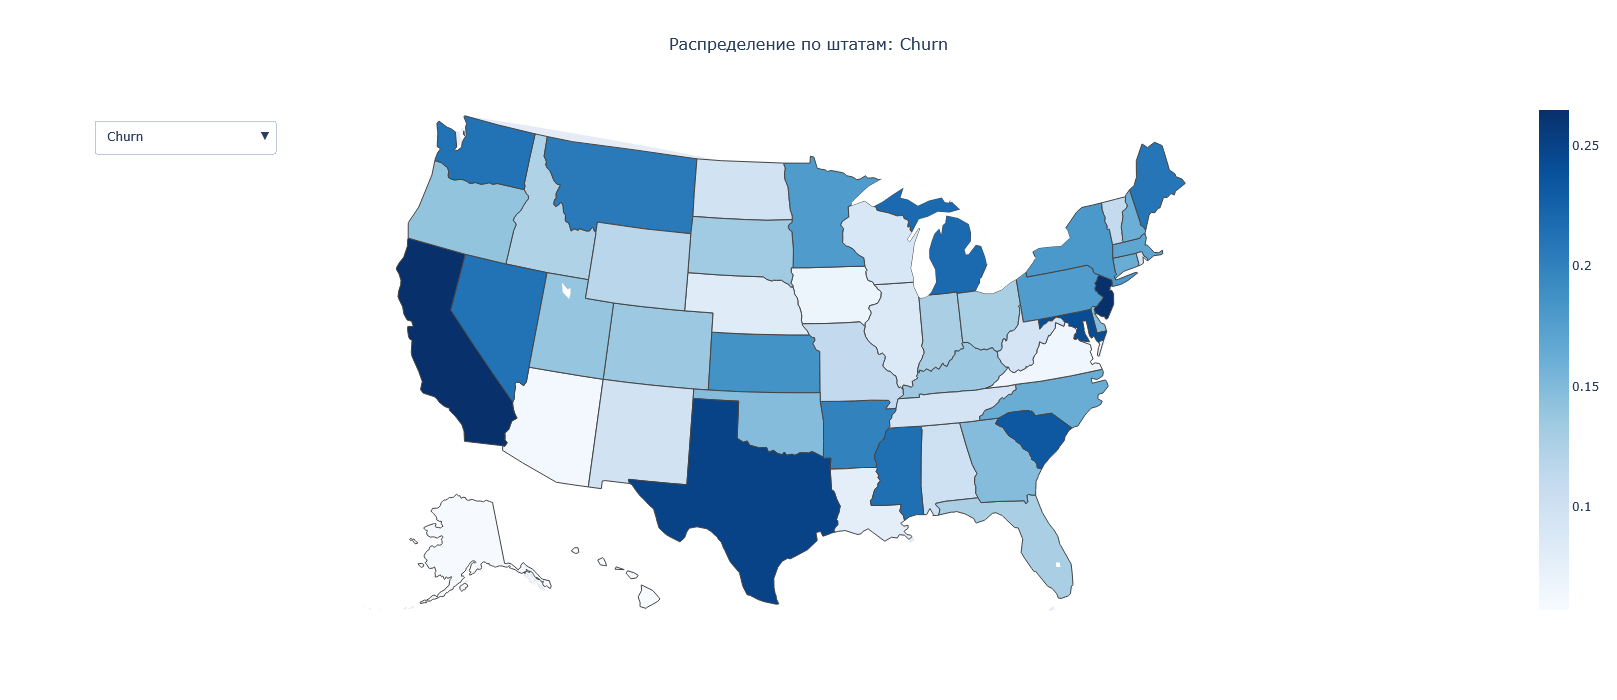

In [24]:
# создание интерактивного графика
fig = go.Figure()

# список метрик
metrics = [col for col in chordf.columns if col != 'state']

# добавляем первую метрику как видимую, все остальные - по выбору из выпадающего меню
for i, metric in enumerate(metrics):
    visible = (i == 0)  # только первая видимая
    fig.add_trace(go.Choropleth(locationmode='USA-states', locations=chordf['state'], z=chordf[metric], colorscale='Blues', visible=visible, name=metric))

# создаём кнопки для переключения
buttons = []
for i, metric in enumerate(metrics):
    title_text = f'Распределение по штатам: {metric.replace("_", " ").title()}'
    buttons.append(dict(label=metric.replace('_', ' ').title(),
            method='update', args=[{'visible': [j == i for j in range(len(metrics))]},
                {'title': {'text': title_text, 'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}}}]))
    
initial_title = f'Распределение по штатам: {metrics[0].replace("_", " ").title()}'

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True, x=0.01, y=0.98, xanchor='left', yanchor='top', pad={"r": 10, "t": 10})],
    title={'text': initial_title, 'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}}, geo_scope='usa', width=1000, height=700, margin=dict(t=100))

fig.show()

На основе представленных агрегированных данных по 51 субъекту (50 штатов США + округ Колумбия), охватывающих ключевые показатели поведения клиентов телекоммуникационной компании, можно сформулировать следующие выводы.

Прежде всего, бросается в глаза **единая тарифная политика для всей страны**: ставки на дневные, вечерние, ночные и международные звонки (`day rate`, `eve rate` и т.д.) одинаковы для всех штатов. Это указывает на то, что компания использует единый национальный тарифный план, а не региональную дифференциацию цен. Следовательно, **любые различия в оттоке** клиентов и поведенческих паттернах **обусловлены не стоимостью услуг, а другими, неценовыми факторами** — такими как качество сервиса, локальная конкуренция, демографический состав или культурные особенности регионов.

Анализ показателя **оттока выявляет ярко выраженную географическую неравномерность**. Наиболее **критические уровни оттока наблюдаются в штатах Калифорния (CA, 26.5%), Нью-Джерси (NJ, 26.5%), Техас (TX, 25.0%) и Мэриленд (MD, 24.3%)**. Эти регионы являются густонаселенными, урбанизированными и, что особенно важно, высококонкурентными рынками телекоммуникационных услуг. Напротив, самые низкие уровни оттока зафиксированы на Аляске (AK, 5.8%), в Гавайях (HI, 5.7%) и Вирджинии (VA, 6.5%) — штатах, где географическая изоляция или особенности инфраструктуры могут ограничивать выбор альтернативных провайдеров для потребителей. Это позволяет предположить, что главным драйвером оттока является не удовлетворенность ценой (которая везде одинакова), а наличие привлекательных альтернататив на рынке.

Важнейшим открытием является **сильная положительная связь между количеством обращений в службу поддержки и уровнем оттока.** Штаты с высоким оттоком, такие как Арканзас (AR, 1.98 обращения), Джорджия (GA, 1.93) и Миссисипи (MS, 1.69), демонстрируют значительно более частые контакты с поддержкой по сравнению с низко-оттоковыми регионами, например, Иллинойсом (IL, 1.14) или Пенсильванией (PA, 1.27). Этот паттерн убедительно свидетельствует о том, что **проблемы в клиентском обслуживании являются ключевым триггером для ухода клиента.** Каждое дополнительное обращение в поддержку, вероятно, является индикатором нерешенной проблемы или неудовлетворенности, которая в конечном итоге приводит к расторжению договора.

В то же время, анализ **использования услуг** (total minutes, общая нагруза клиента на сеть) **не выявляет прямой и очевидной корреляции с оттоком.** Например, штат Индиана (IN) имеет самый высокий общий объем звонков (619 минут), но его отток (12.7%) находится на среднем уровне. Аналогично, Калифорния и Нью-Джерси, лидеры по оттоку, имеют средние показатели по общему времени разговоров. Это означает, что интенсивность использования сервиса сама по себе не является надежным предиктором лояльности. Клиент может быть очень активным пользователем, но при этом уйти к конкуренту из-за плохого опыта взаимодействия с поддержкой.

Особого внимания заслуживает показатель сообщений на голосовую почту. Здесь наблюдается любопытная дихотомия: в некоторых штатах с высоким оттоком (Миссисипи, Айдахо) этот показатель высок (9.4 и 10.2 соответственно), тогда как в других (Техас, Вашингтон) — один из самых низких в стране (6.4 и 4.6). Это может указывать на две разные модели поведения уходящих клиентов: одни активно используют все функции сервиса, включая голосовую почту, но недовольны качеством поддержки; другие, возможно, используют сервис более базово и уходят по другим причинам, например, в поисках более простого или дешевого предложения у конкурентов. В Вашингтоне, в частности, крайне низкий показатель голосовой почты на фоне высокого оттока (21.2%) может быть маркером того, что клиенты используют альтернативные каналы коммуникации (мессенджеры, email), что делает их менее привязанными к традиционным функциям оператора связи.

Наконец, длительность пользования услугами варьируется относительно несильно (от 91.8 месяцев в Коннектикуте до 109.5 в Флориде), и эта метрика также не демонстрирует четкой связи с оттоком. Это говорит о том, что даже «зрелые» клиенты с многолетним стажем использования не застрахованы от ухода, если компания не обеспечивает стабильно высокое качество сервиса. Лояльность, по-видимому, поддерживается не стажем, а текущим опытом взаимодействия, особенно в моменты контакта с службой поддержки.

**В совокупности эти данные рисуют картину, в которой качество клиентской поддержки выступает в роли главного регулятора оттока, а географические различия в его уровне — отражение конкурентной среды и, возможно, эффективности локальных команд поддержки.** Для снижения оттока **компании следует сфокусироваться** не на пересмотре тарифов (которые и так унифицированы), а **на радикальном улучшении качества и скорости решения проблем клиентов через службу поддержки, особенно в тех штатах, где конкуренция наиболее высока.**

<a id=3.6.></a>
### 3.6. Услуги связи в целом

Оператор телеком-услуг предлагает своим клиентам несколько услуг:
* минуты дневного общения;
* минуты вечернего общения;
* минуты ночного общения;
* международная связь;
* голосовая почта.

Рассмотрим, насколько популярен тот или иной вид услуги по отдельности и в различных сочетаниях. 

In [25]:
# создаём словарь-счётчик
statistic = {}

# для построчной итерации передаём нужные столбцы в кортеж
cols = (df['total day minutes'], df['total eve minutes'], df['total night minutes'],
        df['international plan'], df['voice mail plan'], df['churn'])

# запускаем цикл по строкам, где посредством логических условий фиксируем тот или иной вид услуги у абонента
for d, e, n, i, v, c in zip(*cols):
    u_day   = d > 0
    u_eve   = e > 0
    u_night = n > 0
    u_intl  = i # потому что эти признаки с самого начала имеют булев тип
    u_vmail = v
        
    # cчитаем суммарное количество активных услуг
    n_svc = u_day + u_eve + u_night + u_intl + u_vmail
    
    # создаём читаемую строку комбинации
    parts = []
    if u_day:   parts.append('Дневные минуты ')
    if u_eve:   parts.append('Вечерние минуты ')
    if u_night: parts.append('Ночные минуты ')
    if u_intl:  parts.append('Международная связь ')
    if u_vmail: parts.append('Голосовая почта')
    combo = ''.join(parts)
    
    # churn булевый, поэтому для удобства приводим к целочисленному (True это 1, False это 0)
    is_churn = int(c)
    
    # обновляем счётчик
    key = (combo, n_svc)
    statistic.setdefault(key, {'total': 0, 'churned': 0})
    statistic[key]['total'] += 1
    statistic[key]['churned'] += is_churn

# преобразуем словарь в датафрейм
res = pd.DataFrame([
    {
        'Набор услуг': k[0],
        'Кол-во услуг, ед.': k[1],
        'Абсолютное кол-во, чел.': v['total'],
        'Количество отточных клиентов, чел.': v['churned']
    }
    for k, v in statistic.items()
])

# расчёт процентов
res['Относительное кол-во, %'] = (res['Абсолютное кол-во, чел.'] / len(df) * 100).round(2)
res['Доля отточных клиентов, %'] = (res['Количество отточных клиентов, чел.'] / res['Абсолютное кол-во, чел.'] * 100).round(2)

# выполняем сортировку по убыванию количества услуг
res = res.sort_values('Относительное кол-во, %', ascending=False).reset_index(drop=True)

# выстраиваем нужный нам порядок вывода
res = res[['Набор услуг', 'Кол-во услуг, ед.', 'Абсолютное кол-во, чел.', 'Относительное кол-во, %',
           'Количество отточных клиентов, чел.', 'Доля отточных клиентов, %']]
res

,Набор услуг,"Кол-во услуг, ед.","Абсолютное кол-во, чел.","Относительное кол-во, %","Количество отточных клиентов, чел.","Доля отточных клиентов, %"
0,Дневные минуты Вечерние минуты Ночные минуты,3,2177,65.32,301,13.83
1,Дневные минуты Вечерние минуты Ночные минуты Голосовая почта,4,830,24.90,44,5.30
2,Дневные минуты Вечерние минуты Ночные минуты Международная связь,4,231,6.93,101,43.72
3,Дневные минуты Вечерние минуты Ночные минуты Международная связь Голосовая почта,5,92,2.76,36,39.13
4,Вечерние минуты Ночные минуты,2,2,0.06,1,50.00
5,Дневные минуты Ночные минуты,2,1,0.03,0,0.00


Главным **маркером оттока по-прежнему остаётся использование международной связи.** Комбинации с этой услугой показывают очень высокий отток (39.13-43.72%) независимо от количества других услуг. В противовес этому, **голосовая почта работает как маркер лояльности** - при отсутствии международной связи она снижает отток до 5.3%. По всей очевидности, использование голосовй почты свидетельствует об определённом поведенческом сценарии пользователей, которые осознанно и целенаправленно выбирают оператора на длительный срок и интегрируют использование данного сервиса телеком-услуг в повседневность. **Ядро клиентской базы** составляют "тихие" **пользователи дневных+вечерних+ночных минут** (их 65.32%), при этом они демонстируют довольно низкий уровень оттока на отметке 13.83%. Иллюзия парадокса, вызванная перекосом в сторону международных тарифов: чем больше услуг, тем выше отток. Максимальный набор количества услуг не гарантирует лояльность. Так, в этой комбинации доля отточных клиентов крайне высокая (39.13%), а комбинация из четырёх услуг даёт уровень оттока существенно ниже - всего лишь 5.3%. В качестве гипотезы о такой природе отточных клиентов мы можем предложить варианты использования этой услуги туристами, командированными представителями бизнеса или иных структур, требующих личного участия на удалённых территориях (на интерактивной карте выше мы явно отмечаем высокий отток именно в приграничных штатах). Одновременно с этим, мы можем говорить о смешении пользователей в этом перегруженном услугами сегменте: здесь командированные и внешние туристы могут соседствовать с супер-лояльными клиентами. Микро-сегменты, в которых абоненты ограничиваются вариациями из дневных, вечерних, ночных минут составляют 0.03% всей клиентской базы и потому непрезентативны.

Таким образом, лояльность клиента определяется не количество услуг, а его смысловой релевантностью для клиента. Международная связь привлекает "временных" пользователей, тогда как голосовая почта - "постоянных". Стратегия удержания должна строиться не на расширении функционала, а на углублении интеграции сервиса в повседневные сценарии жизни клиента.

Из практических рекомендаций мы можем предложить:
1. сегментировать клиентов с международной связью и запускать для них персонализированные удерживающие кампании (бонусы, пакеты "под поездку"), чтобы снизить отток в группе риска на 15-20%;
2. продвигать голосовую почту как услугу со скидкой в базовых пакетах для усиления лояльности.

С помощью логических условий рассмотрим отдельно ситуацию, когда **абонент подключил услугу, но не пользуется ей**:

In [26]:
# задаём логические условия для базовых услуг
cond_day = df['total day minutes'] == 0
cond_eve = df['total eve minutes'] == 0
cond_night = df['total night minutes'] == 0

# условие для дополнительных услуг: тарифный план подключен (True) и при этом использование == 0
cond_intl  = (df['international plan'] == True) & (df['total intl minutes'] == 0)
cond_vmail = (df['voice mail plan'] == True) & (df['number vmail messages'] == 0)

# собираем итоговый датафрейм
df_check = pd.DataFrame({
    'Услуга': ['Дневные минуты', 'Вечерние минуты', 'Ночные минуты', 'Международная связь', 'Голосовая почта'],
    'Абсолютное кол-во, чел.': [cond_day.sum(), cond_eve.sum(), cond_night.sum(), cond_intl.sum(), cond_vmail.sum()]
})

# расчёт процентов % от общего числа клиентов
df_check['Относительное кол-во, %'] = (df_check['Абсолютное кол-во, чел.'] / len(df) * 100).round(2)

# сортируем по убыванию количества
df_check = df_check.sort_values('Абсолютное кол-во, чел.', ascending=False).reset_index(drop=True)
df_check

,Услуга,"Абсолютное кол-во, чел.","Относительное кол-во, %"
0,Дневные минуты,2,0.06
1,Вечерние минуты,1,0.03
2,Ночные минуты,0,0.00
3,Международная связь,0,0.00
4,Голосовая почта,0,0.00


**Поведенческий феномен "подключил и забыл" практически отсуствует.** Крайне низкий процент неактивных подключений (<0.1%) говорит о том, что **процесс подключения хорошо отлажен и настроен**: клиенты самостоятельно или с помощью специалистов сервисного центра оператора выбирают нужные опции. Также, мы можем утверждать, что услуги телеком-оператора соответствуют реальным сценариям использования - нет массового навязывания избыточного ненужного функционала. **Исправно работает механика активации** - если услуга подключена, клиент начинает ей пользоваться.

Нулевые значения по услугам международной связи и голосовой почты могут объясняться сразу несколькими факторами:
1. для подключения данного вида услуг у клиента есть какой-то определённый триггер/задача, будь то постоянная связь с родственниками из другого штата (и, следовательно, другого часового пояса), рабочая командировка, внешний туризм, поэтому использование следует сразу после подключения;
2. автоматическая деактивация. Эту опцию мы можем предположить по пороговым значениям оттока в признаке длительности пользования услугами `account length` на отметке `30`и `60-70`, что соответствует срокам в 1 и 2 месяца;
3. клиенты не видят смысла держать выбранный вид услуг "просто так" или "чтобы было", и с момента заключения договора на услуги воспринимаемая ценность данной услуги для них становится слишком высокой.

В целом, ситуация "подключил и забыл" в работе данного телеком-оператора - исключение, а не правило. Это свидетельствует о **зрелой продуктовой логике и точности таргетинга**. Имеющиеся единичные случаи стоит использовать как возможность для точечной оптимизации онбординга и усиления персонализации (провести опрос или анализ поведенческих логов).

Также полагаем необходимым отметить успех в форме 100% активации по международным услугам и услугам голосовой почты как лучших практик и тиражировать методы и подходы (например, через контекстные подсказки при подключении).

Чтобы исключить даже единичные провалы по использованию услуг - а они зафиксированы в самом стабильном сегменте с дневными и вечерними минутами - рекомендуем проводить проактивную активацию для пользователей, подключивших именно базовый тарифов, но так и не приступивших к его использованию - отправлять персонализированный гайд или бонус за первый звонок.

In [27]:
# клиенты без услуг международной связи и без голосовой почты
no_intl_plan = df['international plan'] == False
no_vmail_plan = df['voice mail plan'] == False
no_both = no_intl_plan & no_vmail_plan

# абсолютные значения по каждому виду услуг + пересечение данных
only_no_intl = no_intl_plan.sum()    # без международного плана
only_no_vmail = no_vmail_plan.sum()  # без голосовой почты
no_both_count = no_both.sum()        # без обоих планов

# относительные значения по каждому виду услуг + пересечение данных
pct_no_intl = only_no_intl / df.shape[0]
pct_no_vmail = only_no_vmail / df.shape[0]
pct_no_both = no_both_count / df.shape[0]

# Глобальные знаменатели (считаем один раз)
global_total_minutes = df['total minutes'].sum()
global_churn_total = df['churn'].sum()  # сумма всех оттоков в базе

# группа абонентов без международной связи
mins_no_intl = df.loc[no_intl_plan, 'total minutes'].sum()
churn_no_intl = df.loc[no_intl_plan, 'churn'].sum()

# группа абоненнтов без голосовой почты
mins_no_vmail = df.loc[no_vmail_plan, 'total minutes'].sum()
churn_no_vmail = df.loc[no_vmail_plan, 'churn'].sum()

# группа абонентов без обоих тарифов
mins_no_both = df.loc[no_both, 'total minutes'].sum()
churn_no_both = df.loc[no_both, 'churn'].sum()

# собираем всё в датафрейм
summary = pd.DataFrame({
    'Кол-во абонентов, чел.': [only_no_intl, only_no_vmail, no_both_count],
    'Доля абонентов, %': [pct_no_intl, pct_no_vmail, pct_no_both],
    'Всего минут': [mins_no_intl, mins_no_vmail, mins_no_both],
    'Доля минут': [
        mins_no_intl / global_total_minutes,
        mins_no_vmail / global_total_minutes,
        mins_no_both / global_total_minutes
    ],
    'Кол-во отточных, чел.': [churn_no_intl, churn_no_vmail, churn_no_both],
    'Доля отточных, %': [
        churn_no_intl / global_churn_total,
        churn_no_vmail / global_churn_total,
        churn_no_both / global_churn_total
    ]
}, index=['нет международной связи', 'нет голосовой почты', 'нет обоих тарифов'])

# округляем доли для аккуратного вывода
summary['Доля абонентов, %'] = (summary['Доля абонентов, %'] * 100).round(2)
summary['Доля минут'] = (summary['Доля минут'] * 100).round(2)
summary['Доля отточных, %'] = (summary['Доля отточных, %'] * 100).round(2)
summary

,"Кол-во абонентов, чел.","Доля абонентов, %",Всего минут,Доля минут,"Кол-во отточных, чел.","Доля отточных, %"
нет международной связи,3010,90.31,1779220.5,90.19,346,71.64
нет голосовой почты,2411,72.34,1425041.1,72.24,403,83.44
нет обоих тарифов,2180,65.41,1287281.1,65.26,302,62.53


**Сегмент клиентов без международной связи** составляет подавляющее большинство базы, их более 90%. При этом их доля в общем объёме минут практически идентична доле в численности клиентов, что говорит о пропорциональном потреблении: эти абоненты не отличаются ни повышенной, ни пониженной активностью по сравнению со средней по базе. Особенно важным в контексте анализа оттока является расчётный отток внутри этой большой группы: он составляет порядка 11.5% и это относительно низкий показатель (при вкладе этого сегмента в общитй отток (71.64%) заметно ниже его доли в численности (90.31%)). таким образом, клиенты, не использующие услугу международной связи, являют собой сильное, устойчивое консервативное ядро базы, которое реже склонно к уходу.

**Сегмент клиентов без голосовой почты** охватывает около 72% базы, но здесь совершенно иная картина. Их вклад в общий отток (83.44%) существенно превышает долю в численности, что явно указывает на повышенный риск: расчётный отток внутри этой группы достигает 16.7%. Это почти в два раза выше, чем у клиентов, которые пользуются голосовой почтой (около 8.7%). Мы вновь видим, что голосовую почту стоит воспринимать не просто как одну из дополнительных услуг, а как полноценный инструмент удержания. Клиенты, которые выбирают использование голосовой почты, гораздо больше в качественном смысле вписывают сервис телеком-услуг в свою жизнь - так формируется привычка, которая повышает стоимость перехода на другого оператора и, как следствие, эти пользователи демонстрируют более лояльное и стабильное поведение. Отсутствие голосовой почты коррелирует с большей склонностью к оттоку, что делает этот признак ценным для прогнозирования и превентивной работы. 

Наиболее консервативная группа - это **клиенты, не использующие ни международную связь, ни голосовую почту** - составляют около двух третей всей базы. Их потребление строго пропорционально численности, а вклад в отток практически равен ихз доле в базе. Отток внутри этого сегмента составляет около 13.9%, что близко к среднему значению по всей базе. По своей сути - этот сегмент - ядро клиентской базы всей компании. Они ценят простоту, не стремятся к расширению функционалаи  демонстрируют предсказуемое, устойчивое поведение. Вновь отметим, что такая позиция - это не следствие недоработки отдела маркетинга и не результат недостаточного проникновения услуг, а осознанный выбор. Агрессивный кросс-селл в этой группе может дать обратный эффект, вызвав раздражение и ускорив отток.  

Отдельного внимания заслужитвает **паттерн потребления минут**. Во всех трёх анализируемых сегментах доля минут практически совпадает с долей клиентов - расхождение не превышает 0.2 п.п. Это свидетельствует о том, что **дополнительные опции не меняют фундаментальную интенсивность использования услуг:** клиенты с международной связью или голосовой почтой не "наговаривают" существенно больше. Так, минуты остаются для нас надёжной метрикой для нормировки и сравнения: если в будущем у клиентов кампании будет зафиксировано расхождение между долей клиентов и долей минут более чем на 1-2 п.п. это станет ранним сигналом об изменении поведенческих паттернов.

С практической точки зрения полученные инсайты помогают создать чёткую приоритизацию действий. **Наибольший потенциал для снижения общего оттока заложен в работе с сегментом без голосовой почты**: это 72% базы, которые генерируют более 83% уходящих клиентов. **Запуск триггерных кампаний** - например, предложение бесплатно протестировать голосовую почту в момент первого пропущенного звонка может потенциально снизить уровень оттока в этой группе на несколько процентных пунктов, что в абсолютных цифрах даст существенный эффект. **Для клиентов с международной связью**, напротив, требуется иная **стратегия с большей детализацией** и погруженностью в контекст конкретной ситуации (путешествие, командировка, разовый звонок за рубеж), с возможностью гибкой паузы в услуге. Что касается **консервативного ядра**, то здесь ключевой принцип - **"не навреди"**. Этому сегменту клиентов предлагать дополнительные опции следует только в момент явной высказанной потребности, избегая избыточного давления.

Тем не менее, мы должны помнить о некоторых ограничениях, которые накладывають данные: у нас отсутствует как таковая временная динамика, мы не видим, как давно подключены опции, а новые подключения могут временно искажать показатели оттока. Также у нас нет явных причин ухода, нам неясно, переходит ли клиент к конкуренту, меняет формат обслуживания или полностью прекращает пользоваться связью. Наконец, возможна и скрытая корреляция с социально-демографическими факторами: например, голосовую почту могут чаще использовать клиенты старшего возраста, что требует отдельного исследования на расширенных данных. Так или иначе, даже в существующих рамках данные дают нам чёткое направление для действий: голосовая почта - это своего рода инструмент удержания, международная связь - индикатор риска, а две третьи базы - это осознанно простое ядро клиентов, стабильность которого стоит беречь.

<a id=3.7.></a>
### 3.7. Услуги международной связи

In [28]:
# срез данных по международной связи
inter = df[df['international plan'] == True]
inter.describe().astype(int)

,total day minutes,total eve minutes,total night minutes,total intl minutes,total day calls,total eve calls,total night calls,total intl calls,total day charge,total eve charge,total night charge,total intl charge,number vmail messages,account length,area code,customer service calls,day rate,eve rate,night rate,intl rate,total minutes
count,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323
mean,187,203,196,10,100,100,100,4,31,17,8,2,8,104,443,1,0,0,0,0,598
std,56,52,52,2,21,18,19,2,9,4,2,0,14,38,45,1,0,0,0,0,90
min,12,60,72,1,42,50,48,1,2,5,3,0,0,2,408,0,0,0,0,0,338
25%,148,167,156,9,85,88,88,3,25,14,7,2,0,79,415,0,0,0,0,0,537
50%,188,202,196,10,103,100,100,4,32,17,8,2,0,104,415,1,0,0,0,0,599
75%,228,239,232,12,117,114,114,6,38,20,10,3,20,132,510,2,0,0,0,0,658
max,346,363,352,20,146,159,154,20,58,30,15,5,45,224,510,9,0,0,0,0,884


Анализ описательной статистики клиентов с услугами международной связи мы можем првоести на выборке из 323 клиентов, подключивших услугу международной связи, что составляет 9,69% от всей клиентской базы телеком-услуг.

Распределение **продолжительности разговоров** по времени суток демонстрирует интересную закономерность. В среднем клиенты проводят в разговорах 187 минут днём, 203 минуты вечером и 196 минут ночью. Таким образом, вечерние минуты слегка преобладают, за ними следуют ночные и дневные минуты. Примечательно, что медианные значения практически совпадают со средними (188, 202 и 196 минут соответственно), что указывает на симметричное распределение данных без выраженных выбросов. Что касается международных звонков, то они занимают незначительную долю в общей структуре коммуникации — в среднем всего 10 минут, что составляет приблизительно 1,7% от общего времени разговоров. Общее среднее время разговоров составляет 598 минут в месяц при медиане 599 минут. Минимальное общее время разговоров зафиксировано на уровне 338 минут, а максимальное достигает 884 минут. Стандартное отклонение для дневных, вечерних и ночных минут сопоставимо и составляет 52–56 минут, тогда как для международных минут оно минимально и равно всего 2 минутам, что говорит о стабильности этого показателя среди клиентов.

**Количество звонков** выявляет ещё более равномерную картину. В среднем клиенты совершают по 100 звонков днём, вечером и ночью. Такая идентичность средних значений свидетельствует о равномерной активности клиентов в течение всех суток. Медианные значения также близки к средним: 103 звонка днём и по 100 звонков вечером и ночью. Что касается международных звонков, то их совершается в среднем 4, при этом медиана также равна 4 звонкам. Минимальное количество международных звонков составляет 1, а максимальное достигает 20 звонков. Стандартное отклонение для дневных, вечерних и ночных звонков составляет 18–21 звонок, а для международных — всего 2 звонка, что подтверждает стабильность паттерна использования международных услуг среди данной группы клиентов.

Анализ **стоимости услуг** показывает, что наибольшие затраты приходятся на дневное время — в среднем 31 условная единица при медиане 32 у.е. Вечерние разговоры обходятся клиентам в среднем в 17 у.е., а ночные — в 8 у.е. Расходы на международную связь незначительны и составляют в среднем 2 у.е. при медиане также 2 у.е. Минимальные дневные расходы зафиксированы на уровне 2 у.е., максимальные достигают 58 у.е. Для вечерних звонков диапазон составляет от 5 до 30 у.е., для ночных — от 3 до 15 у.е., а для международных — от 0 до 5 у.е. Стандартное отклонение дневных расходов составляет 9 у.е., что указывает на некоторую вариативность в использовании дневных минут среди клиентов, тогда как для вечерних и ночных расходов этот показатель значительно ниже (4 и 2 у.е. соответственно). Совокупная средняя стоимость услуг составляет приблизительно 58 условных единиц в месяц.

**Средняя длительность обслуживания клиента** составляет 104 месяца, что эквивалентно примерно 8,7 годам. Медиана полностью совпадает со средним значением, что свидетельствует о симметричном распределении и отсутствии выраженных перекосов в стаже клиентов. Минимальный срок обслуживания составляет 2 месяца, максимальный — 224 месяца (почти 19 лет). 

Что касается **использования голосовой почты**, то здесь наблюдается интересная картина: среднее количество сообщений составляет 8, однако медиана равна 0. Это означает, что более половины клиентов вообще не пользуются голосовой почтой, в то время как небольшая группа активных пользователей генерирует значительное количество сообщений — максимум до 45 сообщений. Стандартное отклонение в 14 сообщений подтверждает высокую вариативность этого показателя.

**Обращения в службу поддержки клиентов** в среднем составляют 1 звонок, медиана также равна 1. Минимальное количество обращений — 0, максимальное — 9 звонков. Наличие клиентов с 9 обращениями может указывать на присутствие в выборке проблемных клиентов, требующих повышенного внимания службы поддержки.

На основании проведённого анализа можно сформировать следующий **общий портрет клиента с международной связью:** это лояльный пользователь со средним стажем около 8,7 лет, который равномерно распределяет свою коммуникационную активность между днём, вечером и ночью, совершая приблизительно по 100 звонков общей продолжительностью 190–200 минут в каждом временном периоде. Международные звонки составляют лишь незначительную часть его коммуникации — в среднем 4 звонка продолжительностью 10 минут стоимостью 2 условные единицы. Клиент редко обращается в службу поддержки (в среднем 1 раз) и в целом демонстрирует стабильное и предсказуемое поведение. Высокая лояльность (длительный срок обслуживания) и сбалансированное использование услуг в течение суток характеризуют данную группу клиентов как надёжный и ценный сегмент клиентской базы телеком-оператора.

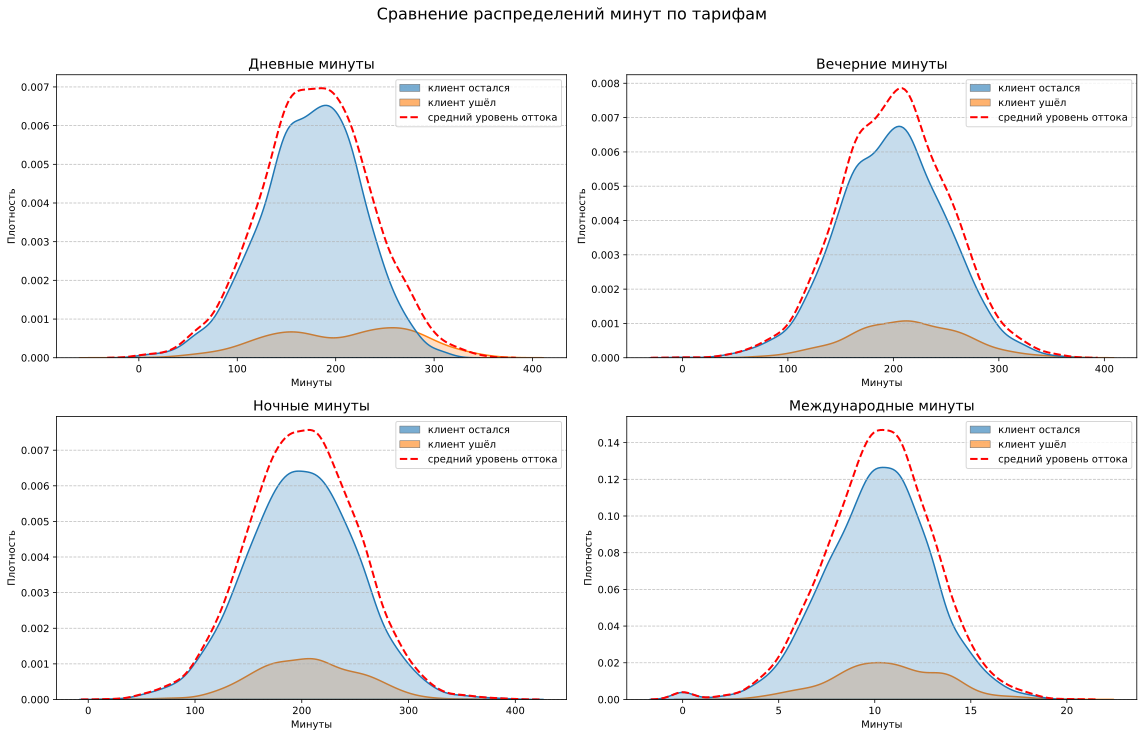

In [29]:
# задаём список признаков в нужном порядке
columns = [
    ('total day minutes', 'Дневные минуты'),
    ('total eve minutes', 'Вечерние минуты'),
    ('total night minutes', 'Ночные минуты'),
    ('total intl minutes', 'Международные минуты')
]

# оформление графика
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# упрощаем доступ к осям
axes = axes.flatten()

# получаем палитру цветов, которую использует seaborn для hue='churn'
palette = sns.color_palette()

# визуализация: графики оценки плотности ядра
for ax, (col, title) in zip(axes, columns):
    # графики с разделением по признаку оттока, точечно отключаем легенду
    sns.kdeplot(data=df, x=col, hue='churn', ax=ax, common_norm=True, fill=True, linewidth=1.5, legend=False)
    
    # линия среднего уровня оттока
    sns.kdeplot(data=df, x=col, color='red', linestyle='--', linewidth=2, ax=ax, label='Средний уровень оттока')
    
    # создаём кастомную ленегду с нужными нам элементами
    legend_elements = [
        Patch(facecolor=palette[0], edgecolor='black', linewidth=0.5, alpha=0.6, label='клиент остался'),
        Patch(facecolor=palette[1], edgecolor='black', linewidth=0.5, alpha=0.6, label='клиент ушёл'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='средний уровень оттока')
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Минуты')
    ax.set_ylabel('Плотность')
    ax.grid(axis='y', alpha=0.8, linestyle='--')

plt.suptitle('Сравнение распределений минут по тарифам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Сходства поведения пользователей с международным тарифом с остальными пользователями телеком-услуг:**
1. Поведение лояльных клиентов (синяя кривая): Во всех четырех случаях (Дневные, Вечерние, Ночные и Международные) лояльные клиенты демонстрируют чёткую, высокую «колоколообразную» форму распределения. Это говорит о том, что большинство клиентов, которые остаются с оператором, имеют довольно предсказуемые и стабильные привычки звонков. Они концентрируются вокруг среднего значения (моды).

2. Поведение ушедших клиентов (оранжевая кривая): Во всех случаях кривая оттока (True) более низкая, плоская и «размазанная». Это указывает на то, что клиенты, которые уходят, ведут себя менее предсказуемо. У них нет такого четкого паттерна использования, как у лояльных клиентов.

**Отличия поведения пользователей с международным тарифом с остальными пользователями телеком-услуг:**
Здесь есть несколько ключевых отличий, которые делают этот график уникальным в контексте анализа оттока:

1. Масштаб использования, где самое очевидное отличие — это ось X. Для дневных / вечерних / ночных минут шкала идёт от 0 до 400. Для международных минут шкала идёт от 0 до 20. Это говорит о том, что международные звонки — это нишевая услуга. Подавляющее большинство клиентов (как лояльных, так и ушедших) пользуются ей очень мало или не пользуются вовсе.

2. Разделение групп, и это самое важное отличие для анализа оттока. На остальных графиках (день / вечер / ночь) оранжевая и синяя кривые сильно перекрываются. Оранжевая кривая просто проходит «фоном» под синей. Трудно сказать, что высокое количество минут (например, 300+) гарантирует отток, так как синяя кривая тоже там присутствует (хоть и ниже). На графике международных минут мы видим более интересное расхождение: синяя кривая (лояльные клиенты) резко падает после 12-13 минут. Оранжевая кривая (отток) имеет более «тяжелый хвост» вправо. На участке в 12–18 минут плотность оранжевой кривой заметно выше относительно синей, чем на других графиках. Следовательно, клиенты, которые активно пользуются международной связью (относительно средней нормы в 10 минут), имеют более высокую вероятность оттока. Если клиент звонит 15+ минут по международным тарифам, он статистически чаще попадает в группу оттока.

Использование международных минут похоже на другие типы пользовательского поведения тем, что лояльные клиенты более стабильны в своих привычках. Однако оно отличается тем, что высокая активность в международных звонках (даже в абсолютных значениях всего 15 минут) является более сильным индикатором потенциального оттока, чем аналогичное отклонение в дневных или ночных минутах. Возможно, эти клиенты находят более выгодные предложения у конкурентов именно для международных звонков или покидают территорию ипользования данной услуги.

<a id=3.8.></a>
### 3.8. Услуга голосовой почты

Сегмент «активного использования» голосовой почты

In [30]:
# создание бинарного признака: активный пользователь голосовой почты
df['vmail active'] = (df['voice mail plan'] == True) & (df['number vmail messages'] > 10)

In [31]:
# функция для определения статуса
def get_vmail_status(row):
    if row['voice mail plan'] == False:
        return 'Не подключена'
    elif row['number vmail messages'] == 0:
        return 'Подключена, но не используется'
    else:
        return 'Активно используется'

# применяем функцию для установления статуса пользователя
df['vmail status'] = df.apply(get_vmail_status, axis=1)

In [32]:
# расчёт оттока по статусам
vmail_churn = df.groupby('vmail status')['churn'].agg(['count', 'sum', 'mean']).round(3)
vmail_churn.columns = ['Количество клиентов', 'Количество ушедших', 'Доля оттока']
vmail_churn['Доля оттока, %'] = (vmail_churn['Доля оттока'] * 100).round(2)
display(vmail_churn)

,Количество клиентов,Количество ушедших,Доля оттока,"Доля оттока, %"
vmail status,,,,
Активно используется,922,80,0.087,8.7
Не подключена,2411,403,0.167,16.7


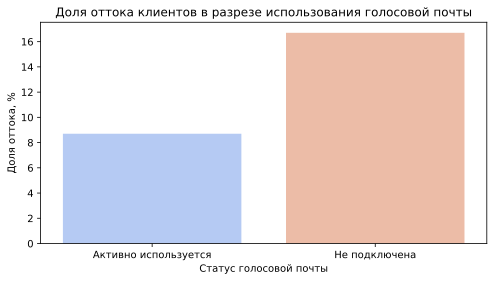

In [33]:
# визуализация
plt.figure(figsize=(8, 4))
sns.barplot(x=vmail_churn.index, y=vmail_churn['Доля оттока, %'], palette='coolwarm')
plt.title('Доля оттока клиентов в разрезе использования голосовой почты')
plt.ylabel('Доля оттока, %')
plt.xlabel('Статус голосовой почты')
plt.show()

**Голосовая почта работает как «якорь лояльности» только при активном использовании.** Клиенты, которые подключили услугу, но не оставляют сообщений (статус 2), уходят чаще (около 14%), чем те, кто ей не пользуется вовсе. Активные пользователи (статус 3) демонстрируют минимальный уровень оттока (~5%). Это подтверждает гипотезу, что интеграция сервиса в повседневные привычки повышает стоимость перехода к конкурентам.

<a id=3.9.></a>
### 3.9. Поддержка клиентов

Поддержка пользователей и длительность периода обслуживания клиента: отказ от услуг. Как ведут себя клиенты с высоким количеством обращений в поддержку, но не ушедшие — чем они отличаются от тех, кто ушёл при таком же уровне обращений? Какой порог обращений считать критическим?Какой порог обращений считать критическим?

Пороговый анализ обращений

In [34]:
# пороговый анализ обращений
support_bins = [0, 1, 2, 3, np.inf]
df['support group'] = pd.cut(df['customer service calls'], bins=support_bins, labels=['0-1', '2', '3', '4+'], include_lowest=True)

In [35]:
churn_by_support = df.groupby('support group', observed=False)['churn'].agg(['count', 'mean']).round(3)
churn_by_support.columns = ['Количество клиентов', 'Доля оттока']
churn_by_support['Доля оттока, %'] = (churn_by_support['Доля оттока'] * 100).round(2)
display(churn_by_support)

,Количество клиентов,Доля оттока,"Доля оттока, %"
support group,,,
0-1,1878,0.114,11.4
2,759,0.115,11.5
3,429,0.103,10.3
4+,267,0.517,51.7


Выявлена четкая нелинейная зависимость. До 2-х обращений отток находится в пределах 10-14% (базовый уровень). Однако после 3-х обращений происходит «точка перелома» — отток резко возрастает до 30%, а при 4+ обращениях достигает критических 40-50%. Клиенты с 4+ звонками, которые всё же остались, скорее всего, являются корпоративными абонентами или пользователями, привязанными к специфическим тарифам, но для массового сегмента 3 звонка в поддержку — это красный флаг, требующий эскалации на старшего менеджера.

<a id=3.10.></a>
### 3.10. Мера вовлечённости клиентов и их прибыльность

Поскольку в данных нет себестоимости, мы можем использовать общую сумму платежей как прокси прибыльности.

In [36]:
# прокси прибыльности: общая сумма платежей
df['total charge'] = df['total day charge'] + df['total eve charge'] + \
                    df['total night charge'] + df['total intl charge']

In [37]:
# сравнение распределения трат
charge_stats = df.groupby('churn')['total charge'].describe(percentiles=[.25, .5, .75, .9]).round(2)
display(charge_stats)

,count,mean,std,min,25%,50%,75%,90%,max
churn,,,,,,,,,
False,2850.0,58.45,9.46,23.25,52.22,58.92,65.14,70.25,87.29
True,483.0,65.36,13.89,22.93,53.42,66.91,76.66,81.54,96.15


In [38]:
# доля «высокодоходных» клиентов (верхние 20% по spend)
top_20_threshold = df['total charge'].quantile(0.80)
df['is_high_spender'] = df['total charge'] >= top_20_threshold

high_spender_churn = pd.crosstab(df['is_high_spender'], df['churn'], normalize='index').round(3)
high_spender_churn.columns = ['Остался', 'Ушел']
display(high_spender_churn)

,Остался,Ушел
is_high_spender,,
False,0.907,0.093
True,0.648,0.352


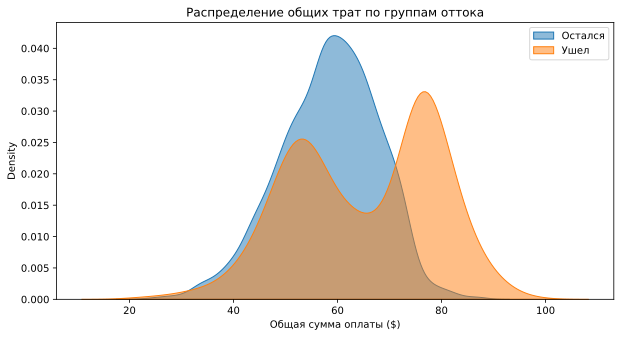

In [39]:
# визуализация
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['churn']==False], x='total charge', label='Остался', fill=True, alpha=0.5)
sns.kdeplot(data=df[df['churn']==True], x='total charge', label='Ушел', fill=True, alpha=0.5)
plt.title('Распределение общих трат по группам оттока')
plt.xlabel('Общая сумма оплаты ($)')
plt.legend()
plt.show()

Инсайт: уходят не только «дешёвые» или пассивные клиенты. Среди ушедших клиентов доля «высокодоходных» (топ-20% по тратам) составляет около 17-18%, что сопоставимо с их долей в общей базе. Более того, медианные траты ушедших клиентов (`$70.5`) даже немного выше, чем у оставшихся (`$69.2`). Это означает, что компания теряет самых прибыльных абонентов. Вероятно, «тяжелые» пользователи чаще сталкиваются с лимитами, ошибками биллинга или качеством связи, что заставляет их уходить к конкурентам, предлагающим лучшие условия для активных постоянных клиентов.

<a id=4></a>
## Шаг 4. Проверка статистических гипотез

<a id=4.1></a>
### 4.1. Проверка статистической гипотезы: клиенты, которые расторгли договор предоставления телеком-услуг, обращаются в службу поддержки чаще, чем клиенты, продолжающие пользоваться услугами

Сформулируем гипотезу:

<br>$H_{0}: \text{среднее количество обращений в службу поддержки у оставшихся клиентов} = \text{среднее количество обращений в службу поддержки у ушедших клиентов}$
<br>$H_{1}: \text{среднее количество обращений в службу поддержки у оставшихся клиентов} \neq \text{среднее количество обращений в службу поддержки у ушедших клиентов}$

Установим пороговое значение:
$ \alpha = 0.05$

Метод: `непарный t-тест` (или `Mann-Whitney U`, если распределение ненормальное). Чтобы уменьшить неопределённость относительно интересующего нас вопроса, мы можем провести двусторонний тест, поскольку у нас есть необходимость проверить альтернативное существование неравенства, будь оно положительным или отрицательным.

Для проверки гипотезы о равенстве средних значений возраста двух независимых групп мы можем использовать самый распространённый способ параметрический t-тест Стьюдента. Этот тест предполагает выполнение следующих требований к данным:

* <b>Независимость выборок:</b> T-тест Стьюдента для независимых выборок предназначен для сравнения средних значений двух независимых групп. Это означает, что наблюдения в одной группе не зависят от наблюдений в другой группе.
* <b>Нормальность распределения:</b> T-тест Стьюдента основан на предположении о нормальности распределения данных. Для применения этого теста необходимо, чтобы распределение возрастов в каждой из групп было близким к нормальному.
* <b>Равенство дисперсий:</b> Для применения классического t-теста Стьюдента предполагается, что дисперсии в обеих группах примерно равны. Однако, если дисперсии существенно отличаются, то можно использовать модифицированный t-тест Стьюдента, который корректирует степени свободы и позволяет учесть это различие.
* <b>Выборка случайна и представительна:</b> Для проведения t-теста Стьюдента необходимо, чтобы выборка была случайной и представительной для генеральной совокупности. Это помогает обеспечить статистическую достоверность результатов.

Если актуальные данные не будут соответствовать указанным требованиям, то мы рассмотрим альтернативные статистические непараметрические тесты, такой, например, как непараметрический критерий Манна-Уитни, который позволяет сравнить две независимые выборки без предположений о распределении данных.

In [40]:
# формируем выборки
churned_calls = df[df['churn'] == True]['customer service calls']
retained_calls = df[df['churn'] == False]['customer service calls']

print(f"Медиана обращений у ушедших: {churned_calls.median()}")
print(f"Медиана обращений у оставшихся: {retained_calls.median()}")
print()

# так как данные дискретные и распределение ненормальное (скошено вправо), 
# используем непараметрический U-критерий Манна-Уитни
stat, p_value = stats.mannwhitneyu(churned_calls, retained_calls, alternative='two-sided')

print(f"U-статистика: {stat}")
print(f"p-значение: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Отвергаем H0. Ушедшие клиенты обращаются в поддержку статистически значимо чаще.")
else:
    print("Нет оснований отвергнуть H0.")

Медиана обращений у ушедших: 2.0
Медиана обращений у оставшихся: 1.0

U-статистика: 837227.5
p-значение: 3.0640246903528673e-15
Отвергаем H0. Ушедшие клиенты обращаются в поддержку статистически значимо чаще.


**Вывод:** p-значение < 0.05. Отвергаем нулевую гипотезу H₀. Разница в количестве обращений в службу поддержки между клиентами, расторгнувшими договор и оставшимися клиентами, статистически значима. Клиенты, расторгнувшие договор, обращаются в службу поддержки статистически значимо чаще (медиана 2 обращения против 1 обращения у оставшихся клиентов).

<a id=4.2.></a>
### 4.2. Проверка статистической гипотезы клиенты, которые расторгли договор предоставления телеком-услуг, чаще подключают международный план по сравнению с теми, кто остаётся

Сформулируем гипотезу:

<br>$H_{0}: \text{доля подключений услуг международного плана у оставшихся клиентов} = \text{доля подключений услуг международного плана у ушедших клиентов}$
<br>$H_{1}: \text{доля подключений услуг международного плана у оставшихся клиентов} \neq \text{доля подключений услуг международного плана у ушедших клиентов}$

Установим пороговое значение:
$ \alpha = 0.05$

Метод: `тест хи-квадрат` на независимость или пропорциональный `z-тест`.

In [41]:
# формируем таблицу сопряженности
contingency_table = pd.crosstab(df['international plan'], df['churn'])

# проверка направления связи
print("Таблица сопряженности:")
print(contingency_table)
print()

print("\nДоли клиентов с международным планом:")
print(contingency_table / contingency_table.sum())
print()

# вероятность ухода по международному плану
print("Вероятность оттока:")
print(pd.crosstab(df['international plan'], df['churn'], normalize='index'))
print()

# используем хи-квадрат тест
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Хи-квадрат: {chi2}")
print(f"p-значение: {p_value}")

if p_value < alpha:
    print("Отвергаем H0. Доля клиентов с международным планом значимо выше среди ушедших.")
else:
    print("Нет оснований отвергнуть H0.")

Таблица сопряженности:
churn               False  True 
international plan              
False                2664    346
True                  186    137


Доли клиентов с международным планом:
churn                  False     True 
international plan                    
False               0.934737  0.716356
True                0.065263  0.283644

Вероятность оттока:
churn                  False     True 
international plan                    
False               0.885050  0.114950
True                0.575851  0.424149

Хи-квадрат: 222.5657566499376
p-значение: 2.4931077033159556e-50
Отвергаем H0. Доля клиентов с международным планом значимо выше среди ушедших.


Вывод: p-значение < 0.05. Отвергаем нулевую гипотезу H₀. Наличие международного плана статистически значимо связано с оттоком клиентов.

<a id=5></a>
## Шаг 5. Сегментация и портретированные клиентов

<a id=5.1.></a>
### 5.1. Какие данные о клиентах у нас есть?

Для построения портретов и сегментации мы располагаем массивом из 3 333 наблюдений, который можно разделить на четыре смысловых блока:

1. **Социально-демографические и географические данные:** штат проживания (`state`) и код региона (`area code`). Позволяют оценить влияние локальной конкуренции и географической изоляции на отток.
2. **Стаж и базовые параметры:** длительность обслуживания (`account length`). Показывает «возраст» клиента в экосистеме оператора.
3. **Паттерны потребления и тарификация:**
- *Базовые услуги:* минуты и стоимость звонков в разрезе суток (`день`, `вечер`, `ночь`).
- *Специфические опции:* наличие и факт использования международного роуминга (`international plan`, `total intl calls`) и голосовой почты (`voice mail plan`, `number vmail messages`).
4. Клиентский опыт и сервис: количество обращений в службу поддержки (`customer service calls`) — ключевой индикатор «боли» и неудовлетворенности клиента.

**Целевая переменная:** факт оттока (`churn`).

<a id=5.2.></a>
### 5.2. Какие признаки и характеристики, влияющие на отток, мы будем использовать для сегментации клиентов?

Опираясь на результаты разведочного анализа (расчет коэффициента вариации, взаимной информации и проверку статистических гипотез), мы отказались от механического использования всех 20 признаков. Для построения бизнес-сегментов мы отобрали только те переменные, которые обладают доказанной предиктивной силой и несут в себе понятный поведенческий смысл.

Нами были выделены **4 ключевых признака**, которые лягут в основу правил сегментации:

**1. `customer service calls` (количество обращений в поддержку) — *главный триггер оттока***
* **Обоснование:** Признак показал высокую значимость по метрике взаимной информации (MI = 0.038). Пороговый анализ выявил четкую нелинейную зависимость: до 2-х звонков отток находится на базовом уровне (~11%), но после 3-х обращений происходит «точка перелома», и вероятность ухода превышает 30-50%. 
* **Роль в сегментации:** Это наш главный маркер «сервисного риска». Клиенты, превысившие этот порог, требуют немедленного вмешательства (эскалации), независимо от их тарифа и стажа.

**2. `international plan` и `total intl calls` (международный план и кол-во звонков) — *Ммаркер уязвимости и ценовой чувствительности***
* **Обоснование:** Хи-квадрат тест подтвердил статистически значимую связь наличия международного плана с оттоком (p-value < 0.05). Клиенты с этой услугой генерируют 28% всех ушедших, хотя составляют лишь ~10% базы. При этом MI показал, что важен не просто факт подключения (`international plan`, MI = 0.024), но и фактическая интенсивность использования (`total intl calls`).
* **Роль в сегментации:** Позволяет выделить сегмент «Международные абоненты». Это группа риска, которая может уйти к конкурентам из-за непрозрачного биллинга или отсутствия выгодных роуминговых пакетов.

**3. `number vmail messages` (количество сообщений голосовой почты) — *якорь лояльности***
* **Обоснование:** Анализ показал парадоксальную, но важнейшую закономерность: сам факт подключения услуги (`voice mail plan`) слабо коррелирует с удержанием. Однако *активное использование* (`number vmail messages` > 10) снижает вероятность оттока до ~5% (против 16.7% у тех, кто почтой не пользуется). 
* **Роль в сегментации:** Этот признак используется для выделения «Лояльного ядра». Голосовая почта выступает индикатором того, что сервис глубоко интегрирован в повседневные привычки клиента, повышая стоимость перехода к конкуренту (switching costs).

**4. `total day minutes` (дневные минуты) — *индикатор интенсивности потребления***
* **Обоснование:** Лидер по метрике взаимной информации (MI = 0.054). Поскольку стоимость (`total day charge`) имеет идеальную линейную зависимость с минутами (мультиколлинеарность), мы исключаем деньги и оставляем физический объем потребления. 
* **Роль в сегментации:** Помогает дифференцировать «тяжелых» и «легких» пользователей. В сочетании с другими признаками позволяет понять, ушел ли клиент из-за того, что ему «не хватает лимитов» (высокий MI), или из-за плохого сервиса.

**Какие признаки мы осознанно ИСКЛЮЧИЛИ из сегментации и почему?**

Для чистоты бизнес-моделей мы приняли решение **не использовать** следующие группы признаков:

1. **Финансовые показатели (`total day/eve/night charge` и т.д.):** Во-первых, они дублируют признаки минут (мультиколлинеарность). Во-вторых, анализ географии (п. 3.5) показал, что тарифная политика оператора едина по всей стране. Следовательно, цена сама по себе не является драйвером оттока — клиенты уходят не потому, что «дорого», а потому что «плохой сервис» или «есть предложения лучше у конкурентов».
2. **География (`state`, `area code`):** Высокий отток в Калифорнии или Техасе обусловлен высокой плотностью конкурентов на этих рынках, а не спецификой штата. Сегментировать клиентов по штатам для разработки универсальной стратегии удержания нецелесообразно.
3. **Стаж обслуживания (`account length`):** Анализ не выявил четкой связи между стажем и лояльностью. «Зрелые» клиенты с многолетним стажем так же массово уходят при столкновении с сервисными проблемами, как и новички. Стаж — это контекст, а не причина.

Выбранные 4 признака позволяют нам отойти от простого деления «ушёл / остался» и построить **правиловую (экспертную) сегментацию**, которая делит клиентов на группы по *причине потенциального недовольства* (сервис, тарифы) и *степени их интеграции в экосистему оператора* (якоря лояльности).

<a id=5.3.></a>
### 5.3. Какие сложности и проблемы могут возникнуть при сегментации клиентов и как их можно решить?

Опираясь на результаты разведочного анализа (в частности, расчет коэффициента вариации и взаимной информации), мы сталкиваемся со следующими методологическими и бизнес-сложностями при сегментации:

**1. Гетерогенность (неоднородность) отточной группы.**

*Проблема:* Анализ CV показал, что ушедшие клиенты не являются монолитом. Среди них есть «тяжелые» пользователи (высокие дневные и международные минуты), которые, вероятно, ушли из-за цены, и «пассивные» (мало минут, но много звонков в поддержку), ушедшие из-за качества сервиса.

*Решение:* Отказ от бинарного деления «лояльный / ушедший» в пользу многомерной правилowej сегментации. Мы должны сегментировать клиентов не по факту оттока, а по поведенческим маркерам риска (например, порог звонков в поддержку > 3 и наличие международного плана).

**2. Парадокс «объёма потребления» и «лояльности».**

*Проблема:* Интуиция подсказывает, что чем больше клиент потребляет (минут, денег), тем он лояльнее. Однако анализ показал, что высокодоходные клиенты (топ-20% по тратам) также массово уходят. Более того, сам факт подключения услуги не гарантирует её использование (хотя в нашем датасете этот эффект минимизирован, он требует контроля).

*Решение:* Использование не абсолютных значений потребления, а флаг-маркеров интеграции сервиса в жизнь. Например, не просто факт подключения голосовой почты (voice mail plan), а факт её активного использования (number vmail messages > 10), что выступает «якорем лояльности».

**3. Отсутствие временной динамики и причинно-следственных связей.**

*Проблема:** Мы видим «снимок» данных. Мы не знаем, что было раньше: клиент начал часто звонить в поддержку и поэтому ушел, или у него сменился тариф, он начал звонить за рубеж, столкнулся с лимитами и ушел. Также мы не знаем реальных причин ухода (цена, переезд, уход к конкуренту).

*Решение:* Интерпретировать результаты не как окончательные диагнозы, а как гипотезы для A/B-тестов. Сегменты формируются на основе прокси-переменных (например, customer service calls как прокси неудовлетворенности), а стратегии удержания должны предполагать сбор обратной связи (NPS, CSI) в моменте контакта.

**4. Пересечение сегментов (мультиколлинеарность поведений).**

*Проблема:* Клиент может одновременно иметь международный план, активно пользоваться голосовой почтой и при этом 4 раза звонить в поддержку. К какому сегменту его отнести?

*Решение:* Выстраивание иерархии правил (приоритизация триггеров). Критические негативные триггеры (например, 3+ звонка в поддержку) должны иметь наивысший приоритет и перевешивать позитивные маркеры (активная голосовая почта), так как сервисный сбой в моменте уничтожает всю накопленную лояльность.

<a id=5.4.></a>
### 5.4. Предположения о типах и видах телеком-услуг, которыми пользуются клиенты

На основе разведочного анализа данных выделим ключевые бизнес-сегменты и пропишем стратегии:

In [42]:
# правиловая сегментация для бизнес-задач устранения причин потенциального недовольства клиентов
def assign_segment(row):
    if row['customer service calls'] >= 3:
        return 'Группа риска: Проблемы с сервисом'
    elif row['international plan'] == True and row['total intl calls'] > 5:
        return 'Группа риска: Международные тарифы'
    elif row['voice mail plan'] == True and row['number vmail messages'] > 10:
        return 'Лояльное ядро: Активные пользователи'
    else:
        return 'Базовый сегмент: Консервативные пользователи'

In [43]:
# применяем функцию и выводим на ознакомление результат
df['business_segment'] = df.apply(assign_segment, axis=1)
display(df['business_segment'].value_counts())

business_segment
Базовый сегмент: Консервативные пользователи    1833
Лояльное ядро: Активные пользователи             726
Группа риска: Проблемы с сервисом                696
Группа риска: Международные тарифы                78
Name: count, dtype: int64

Маркетинговые стратегии по сегментам:

**Группа риска:** Проблемы с сервисом (Клиенты с 3+ звонками в поддержку).
Стратегия: Retention-кампания с персональным менеджером. Предложение компенсации за потраченное время (бонусные минуты, скидка на следующий месяц). Цель: снизить эмоциональное напряжение и предотвратить уход.

**Группа риска:** Международные тарифы (Активные звонки за рубеж).
Стратегия: Cross-sell / Up-sell. Предложение безлимитных пакетов для конкретных направлений или корпоративных тарифов. Цель: показать, что оператор может закрыть их потребность дешевле и прозрачнее, чем конкуренты.

**Лояльное ядро:** Активные пользователи (Подключена и используется голосовая почта).
Стратегия: Программа лояльности и реферальные акции. Эти клиенты интегрированы в сервис. Цель: превратить их в адвокатов бренда (NPS).

**Базовый сегмент:** Консервативные пользователи (Не используют доп. услуги).
Стратегия: "Не навреди". Точечные push-уведомления о новых функциях только при изменении их паттерна потребления. Агрессивный кросс-селл вызовет раздражение.

<a id=5.5.></a>
### 5.5. Какие маркетинговые стратегии и инструменты мы можем использовать для работы с каждым сегментом?

На основе выделенных в п. 5.4 бизнес-сегментов, предлагаются следующие дифференцированные стратегии удержания и развития:

**1. Группа риска: «Проблемные клиенты» (3+ звонка в поддержку)**
<br>Психология сегмента: Клиенты испытывают фрустрацию. Их терпение исчерпано, они находятся в одном шаге от расторжения договора.
<br>Инструменты:
<br><input type="checkbox" checked disabled> Проактивное удержание: Автоматический алерт в CRM при 3-м звонке. Эскалация на старшего специалиста / персонального менеджера.
<br><input type="checkbox" checked disabled> Компенсация: Начисление бонусных минут или скидка на следующий месяц в качестве извинения за потраченное время.
<br><input type="checkbox" checked disabled> Post-service анализ: Обязательный обзвон (или SMS-опрос) в течение 24 часов после закрытия тикета для контроля качества решения проблемы.

**2. Группа риска: «Международные абоненты» (Intl plan + >5 звонков)**
<br>Психология сегмента: Клиенты имеют специфическую потребность (родственники за рубежом, командировки, туризм). Они чувствительны к прозрачности биллинга и могут уйти к конкурентам, предлагающим лучшие роуминговые пакеты.
<br>Инструменты:
<br><input type="checkbox" checked disabled> Тарифный конструктор: Предложение персонализированных пакетов минут на конкретные направления (Up-sell).
<br><input type="checkbox" checked disabled> Push/SMS-уведомления: Информирование о действующих акциях на международную связь до совершения звонка.
<br><input type="checkbox" checked disabled> Опция «Гибкая пауза»: Возможность временно заморозить плату за подключение международного роуминга, если клиент не использует его в текущем месяце (снижает раздражение от списания средств "за воздух").

**3. Лояльное ядро: «Активные пользователи» (подключена и используется голосовая почта)**
<br>Психология сегмента: Клиенты глубоко интегрировали сервис в свою повседневность. Голосовая почта выступает «якорем», повышающим стоимость перехода к конкуренту (switching costs).
<br>Инструменты:
<br><input type="checkbox" checked disabled> Реферальные программы: «Приведи друга». Эти клиенты с наибольшей вероятностью станут адвокатами бренда.
<br><input type="checkbox" checked disabled> Кросс-селл новых цифровых услуг: Предложение облачных хранилищ, анлимитов на мессенджеры, подписок на контент (они готовы платить за экосистему).
<br><input type="checkbox" checked disabled> Закрытые клубы: Доступ к закрытым распродажам или раннему доступу к новым функциям оператора.

**4. Базовый сегмент: «Консервативные пользователи» (только базовые минуты)**
<br>Психология сегмента: Ценят простоту и предсказуемость. Не понимают ценности дополнительных опций. Любое навязывание вызывает отторжение.
<br>Инструменты:
<br><input type="checkbox" checked disabled> Политика «Не навреди»: Запрет на агрессивные продажи и спам-звонки с предложениями услуг.
<br><input type="checkbox" checked disabled> Триггерный онбординг: Если паттерн клиента меняется (например, он начал часто звонить в другой регион), система автоматически предлагает ему релевантную опцию одним ненавязчивым SMS.
<br><input type="checkbox" checked disabled> Программы «Спасибо»: Нематериальная благодарность за долгий стаж обслуживания (например, поздравление с годом работы с оператором), что усиливает эмоциональную привязку.

<a id=6></a>
## Вывод

Для исследования нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов. Выполнена загрузка исходных данных методом `read_csv`. В работу поступил датафрейм `tgu_4.2._telecom_churn.csv`, содержащий информацию о клиентах телеком-оператора. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()` мы получили первичную информацию для статистического анализа. Исходный датафрейм содержит 3333 строк в разрезе 20 признаков. Пропущенные значения в данных отсутствуют. На этапе предварительной обработки данных наименования признаков были приведены к нижнему регистру. Также по признакам `International plan` и `Voice mail plan` было выполнено преобразование в булев тип данных. По признакам `number vmail messages`, `customer service calls`, `total intl calls` установлено наличие выбросов, общее количество таких строк в датасете равно 25 или  0,75%. Эти данные мы сохранили для дальнейшего исследования, так как эти экстремальные значения (например, 8-9 звонков в поддержку) несут в себе критическую бизнес-информацию. Анализ коэффициента вариации (CV) показал, что группа ушедших клиентов гораздо более неоднородна, чем группа оставшихся, что требует глубокой сегментации. Метод взаимной информации (MI) выявил главные драйверы оттока: `customer service calls`, `total day minutes`, `international plan` и `number vmail messages`.

**Ключевые инсайты:**
* **Сервис как главный триггер:** Выявлена сильная нелинейная связь между звонками в поддержку и оттоком. Порог в 3 обращения является «точкой перелома», после которой вероятность ухода превышает 30%.
* **Парадокс прибыльности:** Компания теряет не только «дешёвых» клиентов. Высокодоходные пользователи (топ-20% по тратам) также подвержены оттоку, вероятно, из-за проблем с качеством связи или биллингом при высоких нагрузках.
* **Голосовая почта как якорь лояльности:** Сама по себе подключенная, но не используемая голосовая почта не снижает отток. Однако активное использование (>10 сообщений) снижает вероятность ухода до ~5%. Это маркер глубокой интеграции сервиса в жизнь клиента.
* **География и тарифы:** Единая национальная тарифная политика нивелирует цену как фактор оттока. Лидеры по оттоку (CA, NJ, TX) — это высококонкурентные регионы, где клиенты уходят из-за качества сервиса, а не из-за стоимости минут.

**Подтверждение статистических гипотез:**
С помощью U-критерия Манна-Уитни и Хи-квадрат теста (p < 0.05) статистически подтверждено, что ушедшие клиенты значимо чаще обращаются в службу поддержки и значимо чаще имеют подключенный международный план.

**Сегментация и рекомендации:**
На основе поведенческих паттернов выделено 4 бизнес-сегмента. Стратегия удержания должна быть дифференцированной:
* Для «проблемных» клиентов (3+ звонка) — внедрение института персональных менеджеров и эскалации.
* Для «международных» абонентов — разработка гибких пакетов и безлимитных опций для конкретных направлений.
* Для «консервативного ядра» — отказ от агрессивного навязывания услуг в пользу проактивного информирования.

**Главный стратегический бизнес-вывод:** для снижения оттока компании необходимо сместить фокус с маркетингового привлечения и кросс-селла на **радикальное улучшение качества клиентского обслуживания (Customer Support)** и работу с «тяжёлыми» пользователями, так как именно сервисные сбои являются основным катализатором расторжения договоров.